# Automated Customer Reviews — Classification, Clustering & Generative AI Summarization

**Project | Business Case: Automated Customer Reviews**

This notebook implements the 3 main tasks :

***Sentiment CLASSIFICATION** — classify each review as *positive / negative / neutral* based on the star rating, then with a pretrained Transformer model.

***Product category CLUSTERING** — group products into 4 to 6 meta-categories.

***Generative AI SUMMARIZATION** — generate a short article (blog-post style) per meta-category, with the top 3 products, their main complaints, and the worst product to avoid.

The notebook ends with an interactive demo (deployment bonus) built with #############.

> **Team:** Lydia, Marcelo, Don.

> **Date:** 15_06_2026

**ROADMAP**

1. DATASET ACQUISITION

2. DATA UNDERSTANDING

3. CLEANING
4. LABEL CREATION
5. EDA
6. BALANCING
7. BASELINE MODEL : Classification sentiments with pretrained transformer model on HF.
8. COMPARISON MODEL
9. EVALUATION
10. CLUSTERING : create categories products with KMeans
11. SUMMARIZATION : generate short articles summarization with generative AI
12. APP
13. REPORT + DERIVABLES


**1.DATASET ACQUISITION**

1.1 Import libraries

1.2 Data loadind

In [6]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn transformers datasets evaluate accelerate sentence-transformers gradio torch kaggle

In [7]:
import os
import re
import glob
import json
import gzip
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, silhouette_score
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)

from sentence_transformers import SentenceTransformer
import gradio as gr

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


1.3 Project Configuration

This section defines all project paths and execution options.

In [8]:
# ============================================================
# Paths
# ============================================================
DATA_DIR = "data"
PRIMARY_DIR = os.path.join(DATA_DIR, "primary")
LARGER_DIR = os.path.join(DATA_DIR, "larger")
OUTPUT_DIR = "outputs"

os.makedirs(PRIMARY_DIR, exist_ok=True)
os.makedirs(LARGER_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# Dataset limits
# ============================================================
MAX_PRIMARY_ROWS = None          # None = use all available primary rows
MAX_LARGER_ROWS = 100000          # UCSD is huge. Start small.
MAX_BALANCED_PER_CLASS = 10000    # Increase if Colab GPU can handle it
MAX_CLUSTER_ROWS = 5000

# ============================================================
# Model configuration
# ============================================================
BASELINE_MODEL_NAME = "distilbert-base-uncased"
COMPARISON_MODEL_NAME = "roberta-base"
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
SUMMARIZER_MODEL_NAME = "facebook/bart-large-cnn"

RUN_TRAINING = True
RUN_COMPARISON_MODEL = True
RUN_SPECIALIST_MODELS = False    # Set True only if you have enough time/GPU
RUN_GRADIO_APP = True

# Training parameters
NUM_EPOCHS = 2
BATCH_SIZE = 8
LEARNING_RATE = 2e-5
MAX_TOKEN_LENGTH = 128

**2. DATA UNDERSTANDING**

The project requires two datasets.

### Primary dataset — Kaggle

The primary dataset is available on Kaggle. Since Kaggle requires authentication, and we have to download it.

### Larger dataset — UCSD Amazon Reviews



In [9]:
# ============================================================
# PRIMARY DATASET
# ============================================================

from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d datafiniti/consumer-reviews-of-amazon-products -p data/primary --unzip

# After download, the primary CSV should appear inside data/primary/

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/datafiniti/consumer-reviews-of-amazon-products
License(s): CC-BY-NC-SA-4.0
100% 16.3M/16.3M [00:00<00:00, 123MB/s] 



In [10]:
import pandas as pd

df_primary = pd.read_csv("data/primary/1429_1.csv")

print(df_primary.shape)
df_primary.head(10)

(34660, 21)


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42
5,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This amazon fire 8 inch tablet is the perfect ...,Just what we expected,NaN,NaN,tklit
6,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,"Great for e-reading on the go, nice and light ...",great e-reader tablet,NaN,NaN,Droi
7,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,"I gave this as a Christmas gift to my inlaws, ...",Great for gifts,NaN,NaN,Kacy
8,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",

In [11]:
df_primary.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username'],
      dtype='object')

In [12]:
############______________________################

# LARGER DATASET

############______________________################


import os
import json
import gzip
import requests
import pandas as pd
from tqdm import tqdm

LARGER_DIR = "data/larger"
os.makedirs(LARGER_DIR, exist_ok=True)

SAMPLE_PER_CATEGORY = 10000

BASE_URL = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories"

CATEGORIES = [
    "All_Beauty",
    "Amazon_Fashion",
    "Appliances",
    "Arts_Crafts_and_Sewing",
    "Automotive",
    "Baby_Products",
    "Beauty_and_Personal_Care",
    "Books",
    "CDs_and_Vinyl",
    "Cell_Phones_and_Accessories",
    "Clothing_Shoes_and_Jewelry",
    "Digital_Music",
    "Electronics",
    "Gift_Cards",
    "Grocery_and_Gourmet_Food",
    "Handmade_Products",
    "Health_and_Household",
    "Health_and_Personal_Care",
    "Home_and_Kitchen",
    "Industrial_and_Scientific",
    "Kindle_Store",
    "Magazine_Subscriptions",
    "Movies_and_TV",
    "Musical_Instruments",
    "Office_Products",
    "Patio_Lawn_and_Garden",
    "Pet_Supplies",
    "Software",
    "Sports_and_Outdoors",
    "Subscription_Boxes",
    "Tools_and_Home_Improvement",
    "Toys_and_Games",
    "Video_Games"
]

def map_rating_to_sentiment(rating):
    rating = float(rating)
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

def stream_category_sample(category, sample_size=10000):
    url = f"{BASE_URL}/{category}.jsonl.gz"
    rows = []

    print(f"\nStreaming category: {category}")
    print(url)

    try:
        response = requests.get(url, stream=True, timeout=60)
        response.raise_for_status()

        with gzip.GzipFile(fileobj=response.raw) as gz:
            for line in tqdm(gz, desc=category):
                if len(rows) >= sample_size:
                    break

                try:
                    item = json.loads(line.decode("utf-8"))
                except Exception:
                    continue

                text = item.get("text", "")
                title = item.get("title", "")
                rating = item.get("rating", None)

                if not text or rating is None:
                    continue

                review_text = f"{title}. {text}" if title else text

                rows.append({
                    "review_text": review_text,
                    "rating": float(rating),
                    "sentiment": map_rating_to_sentiment(rating),
                    "product_name": item.get("parent_asin", item.get("asin", "Unknown Product")),
                    "raw_category": category,
                    "source": "amazon_reviews_2023"
                })

    except Exception as e:
        print(f"[ERROR] Failed category {category}: {e}")

    return pd.DataFrame(rows)

all_dfs = []

for category in CATEGORIES:
    category_df = stream_category_sample(category, SAMPLE_PER_CATEGORY)

    print(f"{category}: {category_df.shape[0]} reviews collected")

    if not category_df.empty:
        all_dfs.append(category_df)

larger_df = pd.concat(all_dfs, ignore_index=True)

larger_df = larger_df.dropna(subset=["review_text", "rating", "sentiment"])
larger_df = larger_df.drop_duplicates(subset=["review_text"])

output_path = f"{LARGER_DIR}/amazon_reviews_2023_all_categories_sampled.csv"
larger_df.to_csv(output_path, index=False)

print("\nFINAL SHAPE:", larger_df.shape)
print("Saved to:", output_path)

display(larger_df.head())
display(larger_df["raw_category"].value_counts())
display(larger_df["sentiment"].value_counts())


Streaming category: All_Beauty
https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/All_Beauty.jsonl.gz


All_Beauty: 10000it [00:00, 65735.36it/s]


All_Beauty: 10000 reviews collected

Streaming category: Amazon_Fashion
https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Amazon_Fashion.jsonl.gz


Amazon_Fashion: 10000it [00:00, 65566.32it/s]


Amazon_Fashion: 10000 reviews collected

Streaming category: Appliances
https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Appliances.jsonl.gz


...

Video_Games: 10000it [00:00, 35799.67it/s]


Video_Games: 10000 reviews collected

FINAL SHAPE: (317201, 6)
Saved to: data/larger/amazon_reviews_2023_all_categories_sampled.csv


,review_text,rating,sentiment,product_name,raw_category,source
0,Such a lovely scent but not overpowering.. Thi...,5.0,positive,B00YQ6X8EO,All_Beauty,amazon_reviews_2023
1,Works great but smells a little weird.. This p...,4.0,positive,B081TJ8YS3,All_Beauty,amazon_reviews_2023
2,"Yes!. Smells good, feels great!",5.0,positive,B097R46CSY,All_Beauty,amazon_reviews_2023
3,Synthetic feeling. Felt synthetic,1.0,negative,B09JS339BZ,All_Beauty,amazon_reviews_2023
4,A+. Love it,5.0,positive,B08BZ63GMJ,All_Beauty,amazon_reviews_2023


,count
raw_category,
All_Beauty,9905
Subscription_Boxes,9876
Kindle_Store,9860
Amazon_Fashion,9859
Beauty_and_Personal_Care,9830
Appliances,9781
Books,9777
Handmade_Products,9749
Musical_Instruments,9746


,count
sentiment,
positive,258775
negative,33851
neutral,24575


In [13]:
larger_df = pd.read_csv("data/larger/amazon_reviews_2023_all_categories_sampled.csv")

print(larger_df.shape)
larger_df.head()

(317201, 6)


,review_text,rating,sentiment,product_name,raw_category,source
0,Such a lovely scent but not overpowering.. Thi...,5.0,positive,B00YQ6X8EO,All_Beauty,amazon_reviews_2023
1,Works great but smells a little weird.. This p...,4.0,positive,B081TJ8YS3,All_Beauty,amazon_reviews_2023
2,"Yes!. Smells good, feels great!",5.0,positive,B097R46CSY,All_Beauty,amazon_reviews_2023
3,Synthetic feeling. Felt synthetic,1.0,negative,B09JS339BZ,All_Beauty,amazon_reviews_2023
4,A+. Love it,5.0,positive,B08BZ63GMJ,All_Beauty,amazon_reviews_2023


**3. CLEANING**

In this section we define some helper and reusable functions for:

- Cleaning review text.
- Mapping star ratings to sentiment labels.
- Loading the primary Kaggle dataset.
- Loading the larger UCSD dataset.
- Balancing the dataset.
- Training Hugging Face models.
- Plotting evaluation results.

The rating-to-sentiment mapping follows the project brief:

| Star rating | Sentiment |
|---|---|
| 1–2 | Negative |
| 3 | Neutral |
| 4–5 | Positive |

In [14]:
def clean_text(text):
    """Basic text cleaning for review text. It preserves normal word spacing."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r'[^A-Za-z0-9À-ÿ.,!?;:"()€$%&/\-\s]', " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def map_rating_to_sentiment(rating):
    """Maps 1-5 star ratings into the 3 required sentiment classes."""
    try:
        rating = float(rating)
    except Exception:
        return np.nan

    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    elif rating >= 4:
        return "positive"
    return np.nan


label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {0: "negative", 1: "neutral", 2: "positive"}


def normalize_product_name(x):
    """
    Cleans product names while preserving readable spacing.

    Important:
    - Kaggle/Datafiniti often gives real product names.
    - Amazon Reviews 2023 review files often give ASINs instead of real names.
      We do not pretend those ASINs are product names.
    """
    if pd.isna(x):
        return "Unknown Product"

    x = str(x)
    x = x.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    x = re.sub(r",+", ",", x)
    x = re.sub(r"\s*,\s*", ", ", x)      # comma followed by a space
    x = re.sub(r"\s*-\s*", " - ", x)      # readable hyphen separation
    x = re.sub(r"\s+", " ", x)
    x = x.strip(" ,-")

    if len(x) == 0 or x.lower() in {"nan", "none", "null"}:
        return "Unknown Product"
    return x


def is_asin(x):
    """Detects Amazon ASIN-like product identifiers."""
    return bool(re.fullmatch(r"B[0-9A-Z]{9}", str(x).strip()))


def product_id_type(x):
    """Classifies a product identifier as named product, ASIN, or unknown."""
    x = normalize_product_name(x)
    if x == "Unknown Product":
        return "unknown"
    if is_asin(x):
        return "asin"
    return "named_product"


def normalize_category(x):
    """
    Normalizes category values.

    - Kaggle/Datafiniti often has comma-separated category paths.
      We keep only the first level, e.g. 'Electronics,iPad & Tablets' -> 'Electronics'.
    - Amazon Reviews 2023 already has one category name, e.g. 'Books'.
    """
    if pd.isna(x):
        return "Unknown Category"

    x = str(x)
    x = x.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    x = x.replace("[", "").replace("]", "")
    x = x.replace("{", "").replace("}", "")
    x = x.replace("'", "").replace('"', "")
    x = re.sub(r"\s+", " ", x).strip()

    if "," in x:
        x = x.split(",")[0].strip()

    if len(x) == 0 or x.lower() in {"nan", "none", "null"}:
        return "Unknown Category"
    return x


def make_product_display_name(product_name, raw_category):
    """
    Creates a safe display name for EDA and reports.

    Real names are preserved.
    ASIN-only products are shown as category products with the ASIN in parentheses.
    Unknown products remain explicit and can be excluded from product-level charts.
    """
    product_name = normalize_product_name(product_name)
    category = normalize_category(raw_category)

    if product_name == "Unknown Product":
        return "Unknown Product"
    if is_asin(product_name):
        return f"{category} product ({product_name})"
    return product_name


def shorten_label(x, max_len=70):
    """Shortens very long labels for readable plots/tables."""
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 3] + "..."


def find_first_existing_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def stratified_limit_by_category(dataframe, max_rows, category_col="raw_category"):
    """
    Limits a large dataset while preserving category diversity.

    Do not use plain .head(max_rows) here: the Amazon Reviews 2023 sampled CSV may be
    ordered by category, so .head() can silently keep only the first few categories.
    """
    if max_rows is None or len(dataframe) <= max_rows:
        return dataframe.copy().reset_index(drop=True)

    if category_col not in dataframe.columns:
        return dataframe.sample(max_rows, random_state=RANDOM_STATE).reset_index(drop=True)

    n_categories = dataframe[category_col].nunique()
    per_category = max(1, int(np.ceil(max_rows / n_categories)))

    sampled = (
        dataframe
        .groupby(category_col, group_keys=False)
        .apply(lambda x: x.sample(min(len(x), per_category), random_state=RANDOM_STATE))
        .reset_index(drop=True)
    )

    if len(sampled) > max_rows:
        sampled = sampled.sample(max_rows, random_state=RANDOM_STATE).reset_index(drop=True)

    return sampled

In [15]:
def load_primary_dataset(primary_dir):
    """Loads the Kaggle/Datafiniti primary dataset and converts it to the unified schema."""
    files = []
    files.extend(glob.glob(os.path.join(primary_dir, "*.csv")))
    files.extend(glob.glob(os.path.join(primary_dir, "*.tsv")))

    if len(files) == 0:
        print(f"[WARNING] No primary dataset file found in {primary_dir}")
        return pd.DataFrame()

    parts = []

    for file in files:
        print("Loading primary file:", file)

        if file.endswith(".tsv"):
            temp = pd.read_csv(file, sep="\t", low_memory=False)
        else:
            temp = pd.read_csv(file, low_memory=False)

        if MAX_PRIMARY_ROWS is not None:
            temp = temp.sample(min(MAX_PRIMARY_ROWS, len(temp)), random_state=RANDOM_STATE)

        text_col = find_first_existing_column(temp, [
            "reviews.text", "review_text", "text", "reviewText", "reviews"
        ])
        rating_col = find_first_existing_column(temp, [
            "reviews.rating", "rating", "overall", "stars", "reviews.stars"
        ])
        product_col = find_first_existing_column(temp, [
            "name", "product_name", "title", "asins", "asin"
        ])
        category_col = find_first_existing_column(temp, [
            "categories", "primaryCategories", "category", "main_cat"
        ])

        if text_col is None or rating_col is None:
            print("[WARNING] Skipping file because text/rating columns were not found:", file)
            print("Available columns:", temp.columns.tolist())
            continue

        part = pd.DataFrame()
        part["review_text"] = temp[text_col].apply(clean_text)
        part["rating"] = pd.to_numeric(temp[rating_col], errors="coerce")
        part["product_name"] = temp[product_col].apply(normalize_product_name) if product_col else "Unknown Product"
        part["raw_category"] = temp[category_col].apply(normalize_category) if category_col else "Unknown Category"
        part["source"] = "primary"
        parts.append(part)

    if len(parts) == 0:
        return pd.DataFrame()

    return pd.concat(parts, ignore_index=True)


def load_larger_ucsd_dataset(folder, max_rows=None):
    """
    Loads the larger Amazon Reviews 2023 / UCSD-style dataset.

    Supported files in data/larger/:
    - sampled CSV created by the helper cell
    - .jsonl.gz / .json.gz / .json line files

    Important fix:
    For CSV files, we do stratified sampling by category instead of .head(max_rows),
    otherwise the first categories in the file dominate the larger dataset.
    """
    frames = []

    if not os.path.exists(folder):
        print(f"[WARNING] Larger dataset folder not found: {folder}")
        return pd.DataFrame()

    csv_files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".csv")]

    for path in csv_files:
        print(f"Loading larger CSV file: {path}")
        temp = pd.read_csv(path, low_memory=False)

        required_cols = ["review_text", "rating", "product_name", "raw_category", "source"]
        if not all(col in temp.columns for col in required_cols):
            raise ValueError(f"CSV file {path} does not have the expected schema: {required_cols}")

        temp = temp[required_cols].copy()
        temp["review_text"] = temp["review_text"].apply(clean_text)
        temp["rating"] = pd.to_numeric(temp["rating"], errors="coerce")
        temp["product_name"] = temp["product_name"].apply(normalize_product_name)
        temp["raw_category"] = temp["raw_category"].apply(normalize_category)
        temp["source"] = temp["source"].fillna("amazon_reviews_2023")

        temp = stratified_limit_by_category(temp, max_rows=max_rows, category_col="raw_category")
        frames.append(temp)

    json_files = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.endswith(".json") or f.endswith(".json.gz") or f.endswith(".jsonl.gz")
    ]

    for path in json_files:
        print(f"Loading larger JSON file: {path}")
        rows = []
        opener = gzip.open if path.endswith(".gz") else open
        category_from_file = os.path.basename(path).replace(".jsonl.gz", "").replace(".json.gz", "").replace(".json", "")

        with opener(path, "rt", encoding="utf-8") as f:
            for line in f:
                if max_rows is not None and len(rows) >= max_rows:
                    break
                try:
                    item = json.loads(line)
                except Exception:
                    continue

                text = item.get("text", item.get("reviewText", ""))
                title = item.get("title", item.get("summary", ""))
                rating = item.get("rating", item.get("overall", None))

                if not text or rating is None:
                    continue

                review_text = f"{title}. {text}" if title else text
                rows.append({
                    "review_text": clean_text(review_text),
                    "rating": float(rating),
                    "product_name": normalize_product_name(item.get("parent_asin", item.get("asin", "Unknown Product"))),
                    "raw_category": normalize_category(category_from_file),
                    "source": "amazon_reviews_2023"
                })

        if rows:
            temp = pd.DataFrame(rows)
            temp = stratified_limit_by_category(temp, max_rows=max_rows, category_col="raw_category")
            frames.append(temp)

    if not frames:
        print(f"[WARNING] No larger dataset file found in {folder}")
        return pd.DataFrame()

    larger_df = pd.concat(frames, ignore_index=True)
    print("Loaded larger dataset shape:", larger_df.shape)
    return larger_df

In [16]:
def plot_confusion_matrix(y_true, y_pred, title):
    labels = [0, 1, 2]
    label_names = ["negative", "neutral", "positive"]
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=label_names,
        yticklabels=label_names
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [17]:
def tokenize_for_transformer(train_df, test_df, model_name, max_length=256):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = Dataset.from_pandas(train_df[["review_text", "label"]])
    test_dataset = Dataset.from_pandas(test_df[["review_text", "label"]])

    def tokenize(batch):
        return tokenizer(
            batch["review_text"],
            padding="max_length",
            truncation=True,
            max_length=max_length
        )

    train_dataset = train_dataset.map(tokenize, batched=True)
    test_dataset = test_dataset.map(tokenize, batched=True)

    train_dataset = train_dataset.remove_columns(["review_text"])
    test_dataset = test_dataset.remove_columns(["review_text"])

    train_dataset.set_format("torch")
    test_dataset.set_format("torch")

    return tokenizer, train_dataset, test_dataset


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted")
    }


def train_transformer_classifier(
    train_df,
    test_df,
    model_name,
    output_subdir,
    epochs=2,
    batch_size=8,
    learning_rate=2e-5
):
    """
    Fine-tunes a Hugging Face Transformer model for 3-class sentiment classification.
    """
    print("\nTraining model:", model_name)

    tokenizer, train_dataset, test_dataset = tokenize_for_transformer(
        train_df,
        test_df,
        model_name=model_name,
        max_length=MAX_TOKEN_LENGTH
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3,
        id2label=id2label,
        label2id=label2id
    )

    output_path = os.path.join(OUTPUT_DIR, output_subdir)

    args = TrainingArguments(
        output_dir=output_path,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        report_to="none",
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()

    predictions = trainer.predict(test_dataset)
    y_pred = np.argmax(predictions.predictions, axis=-1)
    y_true = test_df["label"].values

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=["negative", "neutral", "positive"]))

    plot_confusion_matrix(y_true, y_pred, f"Confusion Matrix - {model_name}")

    trainer.save_model(output_path)
    tokenizer.save_pretrained(output_path)

    return {
        "model_name": model_name,
        "output_path": output_path,
        "trainer": trainer,
        "tokenizer": tokenizer,
        "y_true": y_true,
        "y_pred": y_pred,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted")
    }

**4. LOAD AND MERGE THE TWO DATASETS**

This section loads:

1. The primary Kaggle/Datafiniti dataset.
2. The larger UCSD Amazon Reviews dataset.

Both datasets are merged into a unified schema, that is required before performing EDA and training the model.

In [18]:
# ============================================================
# Load Primary + Larger Dataset
# ============================================================

primary_df = load_primary_dataset(PRIMARY_DIR)
larger_df = load_larger_ucsd_dataset(LARGER_DIR, max_rows=None)

print("Primary dataset shape:", primary_df.shape)
print("Larger dataset shape:", larger_df.shape)

if primary_df.empty:
    raise ValueError("Primary dataset was not loaded.")

if larger_df.empty:
    raise ValueError("Larger dataset was not loaded.")

# Create sentiment before filtering
primary_df["sentiment"] = primary_df["rating"].apply(map_rating_to_sentiment)
larger_df["sentiment"] = larger_df["rating"].apply(map_rating_to_sentiment)

primary_df = primary_df.dropna(subset=["review_text", "rating", "sentiment"])
larger_df = larger_df.dropna(subset=["review_text", "rating", "sentiment"])

print("\nPrimary sentiment distribution:")
print(primary_df["sentiment"].value_counts())

print("\nLarger sentiment distribution before filtering:")
print(larger_df["sentiment"].value_counts())

# Keep only neutral and negative reviews from the larger dataset
larger_minorities_df = larger_df[
    larger_df["sentiment"].isin(["negative", "neutral"])
].copy()

print("\nLarger dataset after keeping only neutral and negative:")
print(larger_minorities_df["sentiment"].value_counts())

# Final merged dataset:
# full primary dataset + only neutral/negative reviews from larger dataset
df = pd.concat(
    [primary_df, larger_minorities_df],
    ignore_index=True
)

df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("\nMerged dataset shape:", df.shape)
print("\nMerged sentiment distribution:")
print(df["sentiment"].value_counts())

display(df.head())

Loading primary file: data/primary/1429_1.csv
Loading primary file: data/primary/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv
Loading primary file: data/primary/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv
Loading larger CSV file: data/larger/amazon_reviews_2023_all_categories_sampled.csv
Loaded larger dataset shape: (317201, 5)
Primary dataset shape: (67992, 5)
Larger dataset shape: (317201, 5)

Primary sentiment distribution:
sentiment
positive    62547
neutral      2902
negative     2510
Name: count, dtype: int64

Larger sentiment distribution before filtering:
sentiment
positive    258775
negative     33851
neutral      24575
Name: count, dtype: int64

Larger dataset after keeping only neutral and negative:
sentiment
negative    33851
neutral     24575
Name: count, dtype: int64

Merged dataset shape: (126385, 6)

Merged sentiment distribution:
sentiment
positive    62547
negative    36361
neutral     27477
Name: count, dtype: int64


,review_text,rating,product_name,raw_category,source,sentiment
0,Looks and feels cheap. Very thin leather and t...,2.0,B01HFL7CY8,Musical_Instruments,amazon_reviews_2023,negative
1,I love the tablets HD picture is beautiful. Th...,5.0,"All - New Fire HD 8 Tablet, 8 HD Display, Wi -...",Tablets,primary,positive
2,"Okay, but not a beauty box. I was so excited, ...",3.0,B07N1572VL,Subscription_Boxes,amazon_reviews_2023,neutral
3,"Looks nice fit well, low quality materials, ju...",2.0,B07FKP1HQM,Amazon_Fashion,amazon_reviews_2023,negative
4,This is a recycled book.. It was sold a year a...,1.0,B09F753DVV,Kindle_Store,amazon_reviews_2023,negative


LOADING DATASET FROM HUGGING FACE

In [19]:
from datasets import load_dataset

hf_ds = load_dataset("SetFit/amazon_reviews_multi_en")

print(hf_ds)
print(hf_ds["train"].features)

hf_train = hf_ds["train"].to_pandas()

display(hf_train.head())
print(hf_train["label"].value_counts().sort_index())

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
})
{'id': Value('string'), 'text': Value('string'), 'label': Value('int64'), 'label_text': Value('string')}


,id,text,label,label_text
0,en_0964290,Arrived broken. Manufacturer defect. Two of th...,0,0
1,en_0690095,the cabinet dot were all detached from backing...,0,0
2,en_0311558,I received my first order of this product and ...,0,0
3,en_0044972,This product is a piece of shit. Do not buy. D...,0,0
4,en_0784379,went through 3 in one day doesn't fit correct ...,0,0


label
0    40000
1    40000
2    40000
3    40000
4    40000
Name: count, dtype: int64


In [20]:
def hf_label_to_sentiment(label):
    if label in [0, 1]:
        return "negative"
    elif label == 2:
        return "neutral"
    elif label in [3, 4]:
        return "positive"
    else:
        return None

hf_train["sentiment"] = hf_train["label"].apply(hf_label_to_sentiment)

print(hf_train["sentiment"].value_counts())

sentiment
negative    80000
positive    80000
neutral     40000
Name: count, dtype: int64


In [21]:
hf_extra_df = hf_train[
    hf_train["sentiment"].isin(["negative", "neutral"])
].copy()

print(hf_extra_df["sentiment"].value_counts())
display(hf_extra_df.head())

sentiment
negative    80000
neutral     40000
Name: count, dtype: int64


,id,text,label,label_text,sentiment
0,en_0964290,Arrived broken. Manufacturer defect. Two of th...,0,0,negative
1,en_0690095,the cabinet dot were all detached from backing...,0,0,negative
2,en_0311558,I received my first order of this product and ...,0,0,negative
3,en_0044972,This product is a piece of shit. Do not buy. D...,0,0,negative
4,en_0784379,went through 3 in one day doesn't fit correct ...,0,0,negative


In [22]:
# Clean Hugging Face dataset before sampling

hf_clean = hf_train.copy()

# Rename text column to match project schema
hf_clean = hf_clean.rename(columns={
    "text": "review_text"
})

# Keep only useful columns first
hf_clean = hf_clean[
    [
        "review_text",
        "label",
        "sentiment"
    ]
].copy()

# Clean review text
hf_clean["review_text"] = hf_clean["review_text"].fillna("").astype(str)
hf_clean["review_text"] = hf_clean["review_text"].str.replace("\n", " ", regex=False)
hf_clean["review_text"] = hf_clean["review_text"].str.replace("\r", " ", regex=False)
hf_clean["review_text"] = hf_clean["review_text"].str.replace("\t", " ", regex=False)
hf_clean["review_text"] = hf_clean["review_text"].str.replace(r"\s+", " ", regex=True)
hf_clean["review_text"] = hf_clean["review_text"].str.strip()

# Remove empty or too short reviews
hf_clean = hf_clean[hf_clean["review_text"] != ""]
hf_clean = hf_clean[hf_clean["review_text"].str.len() >= 10]

# Remove invalid sentiment
hf_clean = hf_clean.dropna(subset=["sentiment"])

# Keep only negative and neutral
hf_clean = hf_clean[hf_clean["sentiment"].isin(["negative", "neutral"])].copy()

# Remove duplicates before sampling
hf_clean = hf_clean.drop_duplicates(subset=["review_text"])

print("HF clean sentiment distribution:")
print(hf_clean["sentiment"].value_counts())
print("\nNaN check:")
print(hf_clean.isna().sum())

HF clean sentiment distribution:
sentiment
negative    79819
neutral     39907
Name: count, dtype: int64

NaN check:
review_text    0
label          0
sentiment      0
dtype: int64


In [23]:
# Sample 30,000 negative and 30,000 neutral reviews

N_NEGATIVE = 30000
N_NEUTRAL = 30000

hf_negative_30k = hf_clean[hf_clean["sentiment"] == "negative"].sample(
    n=N_NEGATIVE,
    random_state=RANDOM_STATE
)

hf_neutral_30k = hf_clean[hf_clean["sentiment"] == "neutral"].sample(
    n=N_NEUTRAL,
    random_state=RANDOM_STATE
)

hf_30k_extra = pd.concat(
    [hf_negative_30k, hf_neutral_30k],
    ignore_index=True
)

print("Selected HF sample:")
print(hf_30k_extra["sentiment"].value_counts())

Selected HF sample:
sentiment
negative    30000
neutral     30000
Name: count, dtype: int64


In [24]:
# Normalize HF sample to match merged dataset schema

hf_30k_extra["rating"] = hf_30k_extra["label"] + 1
hf_30k_extra["product_name"] = "Unknown Product"
hf_30k_extra["raw_category"] = "Unknown Category"
hf_30k_extra["source"] = "hf_amazon_reviews_multi_en"
hf_30k_extra["label"] = hf_30k_extra["sentiment"].map(label2id).astype(int)

hf_30k_extra = hf_30k_extra[
    [
        "review_text",
        "rating",
        "product_name",
        "raw_category",
        "source",
        "sentiment",
        "label"
    ]
]

print("HF final sample:")
print(hf_30k_extra.shape)
print(hf_30k_extra.isna().sum())
print(hf_30k_extra["sentiment"].value_counts())

display(hf_30k_extra.head())

HF final sample:
(60000, 7)
review_text     0
rating          0
product_name    0
raw_category    0
source          0
sentiment       0
label           0
dtype: int64
sentiment
negative    30000
neutral     30000
Name: count, dtype: int64


,review_text,rating,product_name,raw_category,source,sentiment,label
0,Waste of money! Very flimsy. Broke after a wee...,1,Unknown Product,Unknown Category,hf_amazon_reviews_multi_en,negative,0
1,Does not spin freely on the drone. Drone will ...,1,Unknown Product,Unknown Category,hf_amazon_reviews_multi_en,negative,0
2,dislike clips are impossible to open you need ...,2,Unknown Product,Unknown Category,hf_amazon_reviews_multi_en,negative,0
3,I got this handbag for Christmas. I loved the ...,1,Unknown Product,Unknown Category,hf_amazon_reviews_multi_en,negative,0
4,A little larger than what I needed for phone a...,2,Unknown Product,Unknown Category,hf_amazon_reviews_multi_en,negative,0


In [25]:
# Add HF negative and neutral reviews to merged dataset

df_augmented = pd.concat(
    [df, hf_30k_extra],
    ignore_index=True
)

df_augmented = df_augmented.drop_duplicates(
    subset=["review_text", "rating", "sentiment"]
)

df_augmented = df_augmented.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

print("Original merged sentiment distribution:")
print(df["sentiment"].value_counts())

print("\nAugmented merged sentiment distribution:")
print(df_augmented["sentiment"].value_counts())

print("\nNaN check:")
print(df_augmented.isna().sum())

display(df_augmented.head())

Original merged sentiment distribution:
sentiment
positive    62547
negative    36361
neutral     27477
Name: count, dtype: int64

Augmented merged sentiment distribution:
sentiment
negative    65683
neutral     56630
positive    43042
Name: count, dtype: int64

NaN check:
review_text          0
rating               0
product_name         0
raw_category         0
source               0
sentiment            0
label           105356
dtype: int64


,review_text,rating,product_name,raw_category,source,sentiment,label
0,Not as pretty as the picture. Nice dress but n...,3.0,Unknown Product,Unknown Category,hf_amazon_reviews_multi_en,neutral,1.0
1,DO NOT PURCHASE! We put the drain into the sin...,1.0,Unknown Product,Unknown Category,hf_amazon_reviews_multi_en,negative,0.0
2,I gave this as a gift and it did not work well...,1.0,Unknown Product,Unknown Category,hf_amazon_reviews_multi_en,negative,0.0
3,I have put this in the pool but can’t really s...,3.0,Unknown Product,Unknown Category,hf_amazon_reviews_multi_en,neutral,1.0
4,Beautiful; BUT .... This case is beautiful! 5 ...,3.0,B078N2173S,Cell_Phones_and_Accessories,amazon_reviews_2023,neutral,NaN


In [26]:
# Balance final dataset to 43,000 reviews per sentiment class

TARGET_PER_CLASS = 43000

balanced_df = (
    df_augmented
    .groupby("sentiment", group_keys=False)
    .apply(lambda x: x.sample(n=TARGET_PER_CLASS, random_state=RANDOM_STATE))
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print("Balanced dataset distribution:")
print(balanced_df["sentiment"].value_counts())

display(balanced_df.head())

Balanced dataset distribution:
sentiment
neutral     43000
negative    43000
positive    43000
Name: count, dtype: int64


,review_text,rating,product_name,raw_category,source,sentiment,label
0,its okay its not as i guess.... not as a good ...,3.0,Unknown Product,Unknown Category,hf_amazon_reviews_multi_en,neutral,1.0
1,4 in the thriller/romance series set in Sacram...,3.0,1477824154,Books,amazon_reviews_2023,neutral,NaN
2,Batteries were horrible. As soon as I would pu...,1.0,AmazonBasics AAA Performance Alkaline Batterie...,AA,primary,negative,NaN
3,"Good fit and sun protection, but NOT waterproo...",2.0,B086G93HYF,Patio_Lawn_and_Garden,amazon_reviews_2023,negative,NaN
4,"Missing Halos. Great comfort, even works for s...",3.0,B09J83TDQC,Video_Games,amazon_reviews_2023,neutral,NaN


In [27]:
# Save balanced dataset for final EDA / modelling

BALANCED_OUTPUT_DIR = os.path.join(DATA_DIR, "merged")
os.makedirs(BALANCED_OUTPUT_DIR, exist_ok=True)

balanced_path = os.path.join(
    BALANCED_OUTPUT_DIR,
    "merged_dataset_clean.csv"
)

balanced_df.to_csv(balanced_path, index=False)

print("Balanced dataset saved in:")
print(balanced_path)

print("\nShape:")
print(balanced_df.shape)

print("\nSentiment distribution:")
print(balanced_df["sentiment"].value_counts())

Balanced dataset saved in:
data/merged/merged_dataset_clean.csv

Shape:
(129000, 7)

Sentiment distribution:
sentiment
neutral     43000
negative    43000
positive    43000
Name: count, dtype: int64


## 5. Data Cleaning and Sentiment Label Creation

This section cleans the merged dataset and creates the target variable.

The model does not directly learn from the star rating. The star rating is only used to create the supervised label:

- 1–2 stars → `negative`
- 3 stars → `neutral`
- 4–5 stars → `positive`

Rows with missing rating, missing review text, very short reviews, or duplicate review text are removed.

In [28]:
# ============================================================
# Cleaning, label creation, and safe product display columns
# ============================================================

df["review_text"] = df["review_text"].apply(clean_text)
df["product_name"] = df["product_name"].apply(normalize_product_name)
df["raw_category"] = df["raw_category"].apply(normalize_category)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# Remove rows that cannot support supervised learning.
df = df.dropna(subset=["rating", "review_text"])
df = df[df["review_text"].str.len() >= 10]

# Create supervised target from rating.
df["sentiment"] = df["rating"].apply(map_rating_to_sentiment)
df = df.dropna(subset=["sentiment"])
df["label"] = df["sentiment"].map(label2id).astype(int)

# Product identifier quality fields.
df["product_id_type"] = df["product_name"].apply(product_id_type)
df["product_display_name"] = df.apply(
    lambda row: make_product_display_name(row["product_name"], row["raw_category"]),
    axis=1
)
df["product_display_short"] = df["product_display_name"].apply(lambda x: shorten_label(x, 75))

# Remove exact duplicated review/product/rating rows.
df = df.drop_duplicates(subset=["review_text", "rating", "product_name"])
df = df.reset_index(drop=True)

print("Clean merged dataset shape:", df.shape)
print("Product identifier quality:")
display(df["product_id_type"].value_counts().to_frame("count"))

display(df[[
    "review_text", "rating", "product_name", "product_id_type",
    "product_display_name", "raw_category", "source", "sentiment", "label"
]].tail())

Clean merged dataset shape: (121755, 10)
Product identifier quality:


,count
product_id_type,
named_product,58188
asin,56817
unknown,6750


,review_text,rating,product_name,product_id_type,product_display_name,raw_category,source,sentiment,label
121750,"Not very nice watches but hey, $100 a month, w...",3.0,B09N9TNFKV,asin,Subscription_Boxes product (B09N9TNFKV),Subscription_Boxes,amazon_reviews_2023,neutral,1
121751,Didn t particularly enjoy it.. Meh. Didn t par...,3.0,B002BFZ9MQ,asin,Magazine_Subscriptions product (B002BFZ9MQ),Magazine_Subscriptions,amazon_reviews_2023,neutral,1
121752,"I traded this in after receiving a 7"" at Chris...",5.0,"All - New Fire HD 8 Tablet, 8 HD Display, Wi -...",named_product,"All - New Fire HD 8 Tablet, 8 HD Display, Wi -...",Electronics,primary,positive,2
121753,I got this for my kids and I am able to have p...,5.0,"Fire Kids Edition Tablet, 7 Display, Wi - Fi, ...",named_product,"Fire Kids Edition Tablet, 7 Display, Wi - Fi, ...",Tablets,primary,positive,2
121754,"Good idea, but too hard to get off and on.. Th...",2.0,B091K36S5C,asin,Tools_and_Home_Improvement product (B091K36S5C),Tools_and_Home_Improvement,amazon_reviews_2023,negative,0


In [29]:
print(df["sentiment"].value_counts())

print(df["sentiment"].value_counts(normalize=True)*100)

sentiment
positive    58232
negative    36237
neutral     27286
Name: count, dtype: int64
sentiment
positive    47.827194
negative    29.762227
neutral     22.410579
Name: proportion, dtype: float64


**6. EDA**

EDA was carried out in separate notebooks, stored inside the project's main folder.

## EDA — Conclusion

### Final dataset summary

| Metric | Value |
|---|---|
| Total reviews | 129,000 |
| Unique products | 35,073 |
| Unique categories (raw) | 74 |
| Sources | primary, amazon_reviews_2023, hf_amazon_reviews_multi_en |
| Avg review length | 46.2 words |
| Median review length | 26 words |
| Positive reviews | 43,000 (33.33%) |
| Neutral reviews | 43,000 (33.33%) |
| Negative reviews | 43,000 (33.33%) |

### Key findings

**The primary dataset was severely imbalanced.**
The original Datafiniti/Kaggle dataset contained ~34,600 reviews with
~93% positive, ~4% neutral and ~2% negative. This extreme imbalance
would have prevented any model from learning to detect neutral and
negative sentiment — the minority classes would have been structurally
ignored during training.

**Two augmentation steps were required to reach balance.**

Step 1 — Amazon Reviews 2023 (neutral + negative only):
We streamed neutral and negative reviews exclusively from the McAuley-Lab
Amazon Reviews 2023 dataset across multiple categories
(`Office_Products`, `Grocery_and_Gourmet_Food`, etc.), filtering on
rating at read time to avoid pulling in more positive reviews.
Despite this, the dataset remained imbalanced after this step —
the Amazon Reviews 2023 source is itself positive-heavy, so the
volume of neutral and negative reviews recovered was insufficient
to reach the target balance.

Step 2 — Hugging Face `SetFit/amazon_reviews_multi_en` (neutral + negative only):
A second augmentation was performed using the Hugging Face
`SetFit/amazon_reviews_multi_en` dataset, again filtered to neutral
and negative reviews only. This provided the additional minority-class
volume needed to reach the final target of 43,000 reviews per class.

**Final dataset is perfectly balanced at 33.33% per class.**
After combining all three sources and applying downsampling on the
positive class, the final balanced dataset contains exactly
43,000 positive, 43,000 neutral and 43,000 negative reviews —
a perfect 1:1:1 ratio that ensures no class dominates during
fine-tuning.

**Product and category diversity is substantial.**
With 35,073 unique products across 74 raw categories and 3 distinct
sources, the dataset covers a wide range of product types — from
Amazon electronics (Fire Tablets, Kindle, Echo) to grocery, beauty,
office products and more. This diversity is essential for the
clustering step (Section 10), where we group these 74 raw categories
into 6 meaningful meta-categories.

**Review length is short — consistent with real Amazon reviews.**
The median review length of 26 words (avg 46.2 words) confirms that
most Amazon reviews are short and conversational. This justified
using `max_length=256` tokens for DistilBERT (and later reducing to
128 with dynamic padding for RoBERTa v3) — longer sequences would
have added padding overhead without capturing more signal.

### Why three sources instead of one?

A single large dataset would have been simpler, but the combination
of three complementary sources served a specific purpose:

- **Primary (Datafiniti)**: real product names and clean category labels,
  used as the backbone for the clustering and summarization steps.
- **Amazon Reviews 2023**: large-scale real Amazon reviews, used to
  augment neutral and negative classes with domain-consistent data.
- **Hugging Face SetFit**: multilingual Amazon reviews used as a
  secondary augmentation source to close the remaining class gap
  after Amazon Reviews 2023 alone proved insufficient.

The test set was split **before** any augmentation and kept untouched,
ensuring that evaluation metrics reflect real-world class distribution
and are not inflated by the augmented data.

**6. BALANCING**

In [30]:
# ============================================================
# PERSISTENCE SAFETY CELL - Google Drive + Auto Save/Load Models
# ============================================================
# Purpose:
# - Keep the original notebook almost unchanged.
# - Save trained models to Google Drive.
# - If a trained model already exists, load it instead of training again.
# - Save metrics to JSON.
# - Optionally save train/test datasets if they already exist.
#
# Place this cell AFTER train_transformer_classifier is defined
# and BEFORE any model training cells.

import os
import json
import shutil
import pandas as pd

from google.colab import drive
drive.mount("/content/drive")

# ------------------------------------------------------------
# Persistent project folders
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/NLP_Amazon_Reviews_Project"

PERSISTENT_DATA_DIR = os.path.join(PROJECT_DIR, "data")
PERSISTENT_MERGED_DIR = os.path.join(PERSISTENT_DATA_DIR, "merged")
PERSISTENT_OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")
PERSISTENT_RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(PERSISTENT_DATA_DIR, exist_ok=True)
os.makedirs(PERSISTENT_MERGED_DIR, exist_ok=True)
os.makedirs(PERSISTENT_OUTPUT_DIR, exist_ok=True)
os.makedirs(PERSISTENT_RESULTS_DIR, exist_ok=True)

# ------------------------------------------------------------
# Override only the folders used by the existing notebook
# ------------------------------------------------------------
# This does NOT delete your old code.
# It only redirects future saves to Google Drive.

DATA_DIR = PERSISTENT_DATA_DIR
MERGED_DIR = PERSISTENT_MERGED_DIR
OUTPUT_DIR = PERSISTENT_OUTPUT_DIR
RESULTS_DIR = PERSISTENT_RESULTS_DIR

print("Persistent project folder:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

# ------------------------------------------------------------
# Optional: save datasets if they already exist in memory
# ------------------------------------------------------------

def save_dataframe_if_exists(var_name, filename):
    if var_name in globals():
        path = os.path.join(PERSISTENT_MERGED_DIR, filename)
        globals()[var_name].to_csv(path, index=False)
        print(f"[SAVED] {var_name} -> {path}")
    else:
        print(f"[SKIPPED] {var_name} does not exist yet.")

save_dataframe_if_exists("balanced_df", "merged_dataset_clean.csv")
save_dataframe_if_exists("train_df", "train_df.csv")
save_dataframe_if_exists("test_df", "test_df.csv")
save_dataframe_if_exists("df_for_clustering", "df_for_clustering.csv")

# ------------------------------------------------------------
# Load datasets from Drive if they are missing from memory
# ------------------------------------------------------------

def load_dataframe_if_missing(var_name, filename):
    path = os.path.join(PERSISTENT_MERGED_DIR, filename)

    if var_name not in globals() and os.path.exists(path):
        globals()[var_name] = pd.read_csv(path)
        print(f"[LOADED] {var_name} <- {path}")

load_dataframe_if_missing("balanced_df", "merged_dataset_clean.csv")
load_dataframe_if_missing("train_df", "train_df.csv")
load_dataframe_if_missing("test_df", "test_df.csv")
load_dataframe_if_missing("df_for_clustering", "df_for_clustering.csv")

# ------------------------------------------------------------
# Wrap the existing train_transformer_classifier function
# ------------------------------------------------------------
# If a model exists in Drive, it will be loaded and training skipped.
# If it does not exist, the original function will train and then save.

if "train_transformer_classifier" not in globals():
    raise RuntimeError(
        "train_transformer_classifier is not defined yet. "
        "Move this cell to AFTER the function definition and BEFORE model training."
    )

_original_train_transformer_classifier = train_transformer_classifier

def train_transformer_classifier(
    train_df,
    test_df,
    model_name,
    output_subdir,
    epochs=1,
    batch_size=8,
    learning_rate=2e-5
):
    """
    Persistent wrapper around the original train_transformer_classifier.

    Behaviour:
    - If model exists in Google Drive: load model/tokenizer and metrics.
    - If model does not exist: train using original function, save model and metrics.
    """

    model_output_path = os.path.join(OUTPUT_DIR, output_subdir)
    metrics_path = os.path.join(RESULTS_DIR, f"{output_subdir}_metrics.json")

    model_exists = os.path.exists(os.path.join(model_output_path, "config.json"))

    if model_exists:
        print("=" * 80)
        print(f"[FOUND SAVED MODEL] {output_subdir}")
        print("Skipping training.")
        print("Loading from:", model_output_path)
        print("=" * 80)

        tokenizer = AutoTokenizer.from_pretrained(model_output_path)
        model = AutoModelForSequenceClassification.from_pretrained(model_output_path)

        if os.path.exists(metrics_path):
            with open(metrics_path, "r") as f:
                metrics = json.load(f)

            print("[LOADED METRICS]")
            print("Accuracy   :", metrics.get("accuracy"))
            print("Macro F1   :", metrics.get("macro_f1"))
            print("Weighted F1:", metrics.get("weighted_f1"))
        else:
            metrics = {
                "model_name": model_name,
                "accuracy": None,
                "macro_f1": None,
                "weighted_f1": None,
                "output_path": model_output_path
            }

            print("[WARNING] Model exists but metrics JSON was not found.")

        return {
            "model_name": metrics.get("model_name", model_name),
            "output_path": model_output_path,
            "trainer": None,
            "tokenizer": tokenizer,
            "model": model,
            "accuracy": metrics.get("accuracy"),
            "macro_f1": metrics.get("macro_f1"),
            "weighted_f1": metrics.get("weighted_f1")
        }

    else:
        print("=" * 80)
        print(f"[NO SAVED MODEL FOUND] Training {model_name}")
        print("Output will be saved to Google Drive:")
        print(model_output_path)
        print("=" * 80)

        result = _original_train_transformer_classifier(
            train_df=train_df,
            test_df=test_df,
            model_name=model_name,
            output_subdir=output_subdir,
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate
        )

        # Save metrics separately
        metrics = {
            "model_name": result.get("model_name", model_name),
            "accuracy": result.get("accuracy"),
            "macro_f1": result.get("macro_f1"),
            "weighted_f1": result.get("weighted_f1"),
            "output_path": result.get("output_path", model_output_path)
        }

        with open(metrics_path, "w") as f:
            json.dump(metrics, f, indent=4)

        print("=" * 80)
        print("[MODEL AND METRICS SAVED]")
        print("Model path  :", model_output_path)
        print("Metrics path:", metrics_path)
        print("=" * 80)

        return result

print("\nPersistence wrapper is active.")
print("Future calls to train_transformer_classifier will save/load from Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Persistent project folder: /content/drive/MyDrive/NLP_Amazon_Reviews_Project
DATA_DIR: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data
OUTPUT_DIR: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/outputs
RESULTS_DIR: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/results
[SAVED] balanced_df -> /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/merged/merged_dataset_clean.csv
[SKIPPED] train_df does not exist yet.
[SKIPPED] test_df does not exist yet.
[SKIPPED] df_for_clustering does not exist yet.
[LOADED] train_df <- /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/merged/train_df.csv
[LOADED] test_df <- /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/merged/test_df.csv
[LOADED] df_for_clustering <- /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/merged/df_for_clustering.csv

Persistence wrapper is active.
Future calls to t

**7. BASELINE MODEL**

In [31]:
label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

balanced_df = balanced_df.copy()
balanced_df["label"] = balanced_df["sentiment"].map(label2id).astype(int)

print(balanced_df["sentiment"].value_counts())
print(balanced_df["label"].value_counts().sort_index())

train_df, test_df = train_test_split(
    balanced_df,
    test_size=0.2,
    stratify=balanced_df["label"],
    random_state=42
)

print("Train set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

sentiment
neutral     43000
negative    43000
positive    43000
Name: count, dtype: int64
label
0    43000
1    43000
2    43000
Name: count, dtype: int64
Train set shape: (103200, 7)
Test set shape: (25800, 7)


In [32]:
# ============================================================
# ============================================================
# ============================================================
# ============================================================
# ============================================================
# PERSISTENCE SAFETY CELL - Google Drive + Auto Save/Load Models
# ============================================================
# ============================================================
# ============================================================
# ============================================================
# ============================================================
# Purpose:
# - Use the real mounted Google Drive.
# - Point DATA_DIR / OUTPUT_DIR / RESULTS_DIR to Google Drive.
# - If a trained model already exists, load it instead of training again.
# - If a trained model does not exist, train it and save model + metrics.
#
# Place this cell AFTER train_transformer_classifier is defined
# and BEFORE any model training cells.

import os
import json
import shutil
import pandas as pd

from google.colab import drive
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ------------------------------------------------------------
# 1. Safely mount real Google Drive
# ------------------------------------------------------------

fake_drive_path = "/content/drive"
backup_path = "/content/drive_local_backup"

# If /content/drive exists but is NOT a real mount, move it away.
# This avoids the fake MyDrive problem.
if os.path.exists(fake_drive_path) and not os.path.ismount(fake_drive_path):
    print("/content/drive exists but is NOT mounted.")
    print("Moving local fake /content/drive to:", backup_path)

    if os.path.exists(backup_path):
        shutil.rmtree(backup_path)

    shutil.move(fake_drive_path, backup_path)

# Create clean mount point if needed
os.makedirs(fake_drive_path, exist_ok=True)

# Mount real Drive only if it is not already mounted
if not os.path.ismount(fake_drive_path):
    drive.mount(fake_drive_path, force_remount=True)
else:
    print("Google Drive is already mounted.")

print("Drive mounted:", os.path.ismount(fake_drive_path))

# ------------------------------------------------------------
# 2. Persistent project folders
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/NLP_Amazon_Reviews_Project"

DATA_DIR = os.path.join(PROJECT_DIR, "data")
MERGED_DIR = os.path.join(DATA_DIR, "merged")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MERGED_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("\nPersistent project folder:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("MERGED_DIR:", MERGED_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

# ------------------------------------------------------------
# 3. Check saved datasets
# ------------------------------------------------------------

dataset_paths = {
    "balanced_df": os.path.join(MERGED_DIR, "merged_dataset_clean.csv"),
    "train_df": os.path.join(MERGED_DIR, "train_df.csv"),
    "test_df": os.path.join(MERGED_DIR, "test_df.csv"),
    "df_for_clustering": os.path.join(MERGED_DIR, "df_for_clustering.csv"),
}

print("\nChecking saved datasets:")
for name, path in dataset_paths.items():
    print(f"{name}:", os.path.exists(path), "|", path)

# Save datasets if they exist in memory
def save_dataframe_if_exists(var_name, path):
    if var_name in globals():
        globals()[var_name].to_csv(path, index=False)
        print(f"[SAVED] {var_name} -> {path}")

# Load datasets if they do not exist in memory but exist in Drive
def load_dataframe_if_missing(var_name, path):
    if var_name not in globals() and os.path.exists(path):
        globals()[var_name] = pd.read_csv(path)
        print(f"[LOADED] {var_name} <- {path}")

for name, path in dataset_paths.items():
    save_dataframe_if_exists(name, path)

for name, path in dataset_paths.items():
    load_dataframe_if_missing(name, path)

# ------------------------------------------------------------
# 4. Check that the original training function exists
# ------------------------------------------------------------

if "train_transformer_classifier" not in globals():
    raise RuntimeError(
        "train_transformer_classifier is not defined yet. "
        "Move this cell to AFTER the function definition and BEFORE model training."
    )

# Avoid wrapping the wrapper again if the cell is run multiple times
if "_original_train_transformer_classifier" not in globals():
    _original_train_transformer_classifier = train_transformer_classifier
    print("\nOriginal training function captured.")
else:
    print("\nOriginal training function already captured.")

# ------------------------------------------------------------
# 5. Persistent wrapper around train_transformer_classifier
# ------------------------------------------------------------

def train_transformer_classifier(
    train_df,
    test_df,
    model_name,
    output_subdir,
    epochs=1,
    batch_size=8,
    learning_rate=2e-5
):
    """
    Persistent wrapper around the original train_transformer_classifier.

    Behaviour:
    - If model exists in Google Drive: load model/tokenizer/metrics and skip training.
    - If model does not exist: train using original function, then save metrics.
    """

    model_output_path = os.path.join(OUTPUT_DIR, output_subdir)
    metrics_path = os.path.join(RESULTS_DIR, f"{output_subdir}_metrics.json")

    config_exists = os.path.exists(os.path.join(model_output_path, "config.json"))
    safetensors_exists = os.path.exists(os.path.join(model_output_path, "model.safetensors"))
    bin_exists = os.path.exists(os.path.join(model_output_path, "pytorch_model.bin"))

    model_exists = config_exists and (safetensors_exists or bin_exists)

    print("\n" + "=" * 80)
    print("MODEL CHECK")
    print("Model name:", model_name)
    print("Output subdir:", output_subdir)
    print("Model path:", model_output_path)
    print("config.json:", config_exists)
    print("model.safetensors:", safetensors_exists)
    print("pytorch_model.bin:", bin_exists)
    print("metrics json:", os.path.exists(metrics_path))
    print("=" * 80)

    # --------------------------------------------------------
    # CASE 1: Model already exists
    # --------------------------------------------------------
    if model_exists:
        print(f"\n[FOUND SAVED MODEL] {output_subdir}")
        print("Skipping training.")
        print("Loading from:", model_output_path)

        tokenizer = AutoTokenizer.from_pretrained(model_output_path)
        model = AutoModelForSequenceClassification.from_pretrained(model_output_path)

        if os.path.exists(metrics_path):
            with open(metrics_path, "r") as f:
                metrics = json.load(f)

            print("\n[LOADED SAVED METRICS]")
            print("Accuracy   :", metrics.get("accuracy"))
            print("Macro F1   :", metrics.get("macro_f1"))
            print("Weighted F1:", metrics.get("weighted_f1"))

        else:
            print("\n[WARNING] Model exists but metrics JSON was not found.")
            print("The model will still be loaded, but metrics will be None.")

            metrics = {
                "model_name": model_name,
                "accuracy": None,
                "macro_f1": None,
                "weighted_f1": None,
                "output_path": model_output_path
            }

        return {
            "model_name": metrics.get("model_name", model_name),
            "output_path": model_output_path,
            "trainer": None,
            "tokenizer": tokenizer,
            "model": model,
            "accuracy": metrics.get("accuracy"),
            "macro_f1": metrics.get("macro_f1"),
            "weighted_f1": metrics.get("weighted_f1")
        }

    # --------------------------------------------------------
    # CASE 2: Model does not exist
    # --------------------------------------------------------
    else:
        print(f"\n[NO SAVED MODEL FOUND] Training {model_name}")
        print("Output will be saved to Google Drive:")
        print(model_output_path)

        result = _original_train_transformer_classifier(
            train_df=train_df,
            test_df=test_df,
            model_name=model_name,
            output_subdir=output_subdir,
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate
        )

        metrics = {
            "model_name": result.get("model_name", model_name),
            "accuracy": result.get("accuracy"),
            "macro_f1": result.get("macro_f1"),
            "weighted_f1": result.get("weighted_f1"),
            "output_path": result.get("output_path", model_output_path)
        }

        with open(metrics_path, "w") as f:
            json.dump(metrics, f, indent=4)

        print("\n" + "=" * 80)
        print("[MODEL AND METRICS SAVED]")
        print("Model path  :", model_output_path)
        print("Metrics path:", metrics_path)
        print("=" * 80)

        return result

# ------------------------------------------------------------
# 6. Final confirmation
# ------------------------------------------------------------

print("\nPersistence wrapper is active.")
print("Future calls to train_transformer_classifier will save/load from Google Drive.")

print("\nSaved model availability:")
print(
    "DistilBERT:",
    os.path.exists(os.path.join(OUTPUT_DIR, "baseline_distilbert", "config.json"))
)
print(
    "RoBERTa:",
    os.path.exists(os.path.join(OUTPUT_DIR, "roberta_sentiment_model", "config.json"))
)

print("\nWrapper active:", "_original_train_transformer_classifier" in globals())

Google Drive is already mounted.
Drive mounted: True

Persistent project folder: /content/drive/MyDrive/NLP_Amazon_Reviews_Project
DATA_DIR: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data
MERGED_DIR: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/merged
OUTPUT_DIR: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/outputs
RESULTS_DIR: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/results

Checking saved datasets:
balanced_df: True | /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/merged/merged_dataset_clean.csv
train_df: True | /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/merged/train_df.csv
test_df: True | /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/merged/test_df.csv
df_for_clustering: True | /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/merged/df_for_clustering.csv
[SAVED] balanced_df -> /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/merged/merged_dataset_clean.csv
[SAVED] train_df -> /content/drive/MyDrive/NLP_Amazon_

In [33]:
# ============================================================
# Save a copy of the cleaned PRIMARY dataset for clustering
# ============================================================
# The clustering task uses only the cleaned primary dataset.
# It must NOT use the balanced classification dataset.
#
# Reason:
# - Classification uses the merged + balanced dataset.
# - Clustering should preserve the natural structure of the primary dataset.
# - Therefore, we create a separate copy of primary_df for clustering.

df_for_clustering = primary_df.copy()

print("Dataset saved for clustering from cleaned primary dataset:")
print("Shape:", df_for_clustering.shape)

print("\nSentiment distribution:")
print(df_for_clustering["sentiment"].value_counts())

print("\nSentiment distribution (%):")
print((df_for_clustering["sentiment"].value_counts(normalize=True) * 100).round(2))

# Save clustering dataset to Google Drive
df_for_clustering_path = os.path.join(MERGED_DIR, "df_for_clustering.csv")
df_for_clustering.to_csv(df_for_clustering_path, index=False)

print("\ndf_for_clustering saved to:")
print(df_for_clustering_path)

Dataset saved for clustering from cleaned primary dataset:
Shape: (67959, 6)

Sentiment distribution:
sentiment
positive    62547
neutral      2902
negative     2510
Name: count, dtype: int64

Sentiment distribution (%):
sentiment
positive    92.04
neutral      4.27
negative     3.69
Name: proportion, dtype: float64

df_for_clustering saved to:
/content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/merged/df_for_clustering.csv


In [34]:
# ============================================================
# Step 1: Zero-shot baseline — DistilBERT WITHOUT fine-tuning
# ============================================================
# Before we fine-tune anything, we test the off-the-shelf DistilBERT
# sentiment model directly on our data.
#
# WHY: Most pre-trained sentiment models on HuggingFace are BINARY
# (positive / negative only). They have no concept of "neutral".
# This cell demonstrates that problem concretely:
# → recall for "neutral" will be 0% because the model can never
#   predict a class it wasn't trained on.
# This is the key justification for why fine-tuning is necessary.

zero_shot_pipe = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=MAX_TOKEN_LENGTH,
    device=0 if device == "cuda" else -1
)

# Evaluate on a sample of 500 rows (faster, representative)
sample_eval = test_df.sample(500, random_state=42).copy()

zero_shot_preds = zero_shot_pipe(
    sample_eval["review_text"].tolist(),
    batch_size=32
)

# Map binary output (POSITIVE/NEGATIVE) to our 3-class space
def map_binary_to_3class(label):
    """
    A binary model outputs only POSITIVE or NEGATIVE.
    It structurally cannot predict NEUTRAL — recall for neutral = 0%.
    """
    return "positive" if label == "POSITIVE" else "negative"

sample_eval["zero_shot_pred"] = [
    map_binary_to_3class(p["label"]) for p in zero_shot_preds
]

print("=== ZERO-SHOT BASELINE (no fine-tuning) ===")
print("Model: distilbert-base-uncased-finetuned-sst-2-english")
print()
print(classification_report(
    sample_eval["sentiment"],
    sample_eval["zero_shot_pred"],
    labels=["negative", "neutral", "positive"],
    zero_division=0
))
print()
print("[NOTE] Recall for 'neutral' = 0%: the off-the-shelf binary model")
print("has no neutral class to predict. Fine-tuning is required.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

=== ZERO-SHOT BASELINE (no fine-tuning) ===
Model: distilbert-base-uncased-finetuned-sst-2-english

              precision    recall  f1-score   support

    negative       0.55      0.97      0.70       172
     neutral       0.00      0.00      0.00       166
    positive       0.71      0.86      0.78       162

    accuracy                           0.61       500
   macro avg       0.42      0.61      0.49       500
weighted avg       0.42      0.61      0.49       500


[NOTE] Recall for 'neutral' = 0%: the off-the-shelf binary model
has no neutral class to predict. Fine-tuning is required.


In [35]:
!pip uninstall -y torchvision
import sys
# Force remove torchvision from the current session's memory
for mod in list(sys.modules.keys()):
    if "torchvision" in mod:
        del sys.modules[mod]
print("torchvision removed from session")

torchvision removed from session


In [36]:
# ============================================================
# Step 2: Fine-tune DistilBERT for 3-class sentiment classification
# ============================================================
# We take DistilBERT (pre-trained on general language understanding)
# and adapt it to our specific task: predict negative / neutral / positive.
#
# What changes during fine-tuning:
# - The last classification layer is replaced: 2 outputs → 3 outputs
# - All weights are slightly adjusted on our balanced dataset
#   (103k reviews, 43k per class) using a small learning rate (2e-5)
#   to avoid "forgetting" what the model already knows about language
#   (catastrophic forgetting)
#
# Why DistilBERT as baseline?
# - 40% lighter than BERT, 97% of BERT's accuracy
# - Fast to train (~15 min on Colab GPU)
# - Strong starting point to beat with RoBERTa in Section 8

if RUN_TRAINING:
    print("Starting DistilBERT fine-tuning...")
    print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")
    print(f"Epochs: {NUM_EPOCHS} | Batch size: {BATCH_SIZE} | LR: {LEARNING_RATE}")
    print()

    baseline_result = train_transformer_classifier(
        train_df=train_df,
        test_df=test_df,
        model_name=BASELINE_MODEL_NAME,       # "distilbert-base-uncased"
        output_subdir="baseline_distilbert",
        epochs=NUM_EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE
    )

    print()
    print("=== BASELINE RESULTS (DistilBERT fine-tuned) ===")
    print(f"Accuracy   : {baseline_result['accuracy']:.4f}")
    print(f"Macro F1   : {baseline_result['macro_f1']:.4f}")
    print(f"Weighted F1: {baseline_result['weighted_f1']:.4f}")
    print()
    print("[INFO] Model saved to:", baseline_result['output_path'])

else:
    print("RUN_TRAINING = False — skipping DistilBERT fine-tuning.")
    baseline_result = None

Starting DistilBERT fine-tuning...
Train size: 103200 | Test size: 25800
Epochs: 2 | Batch size: 8 | LR: 2e-05


MODEL CHECK
Model name: distilbert-base-uncased
Output subdir: baseline_distilbert
Model path: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/outputs/baseline_distilbert
config.json: True
model.safetensors: True
pytorch_model.bin: False
metrics json: True

[FOUND SAVED MODEL] baseline_distilbert
Skipping training.
Loading from: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/outputs/baseline_distilbert


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


[LOADED SAVED METRICS]
Accuracy   : 0.8287984496124031
Macro F1   : 0.8285221490172244
Weighted F1: 0.8285221490172245

=== BASELINE RESULTS (DistilBERT fine-tuned) ===
Accuracy   : 0.8288
Macro F1   : 0.8285
Weighted F1: 0.8285

[INFO] Model saved to: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/outputs/baseline_distilbert


**8. COMPARISON MODEL**

In [37]:
#!pip install -U datasets
#!pip uninstall -y torchvision

In [38]:
# ============================================================
# PREPARE LABELS FOR TRANSFORMER MODELS
# ============================================================

label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

train_df = train_df.copy()
test_df = test_df.copy()

train_df["label"] = train_df["sentiment"].map(label2id)
test_df["label"] = test_df["sentiment"].map(label2id)

train_df["label"] = train_df["label"].astype(int)
test_df["label"] = test_df["label"].astype(int)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain distribution:")
print(train_df["sentiment"].value_counts())

print("\nTest distribution:")
print(test_df["sentiment"].value_counts())

Train shape: (103200, 7)
Test shape: (25800, 7)

Train distribution:
sentiment
positive    34400
negative    34400
neutral     34400
Name: count, dtype: int64

Test distribution:
sentiment
positive    8600
neutral     8600
negative    8600
Name: count, dtype: int64


In [39]:
# ============================================================
# 8. COMPARISON MODEL - RoBERTa
# ============================================================

roberta_results = train_transformer_classifier(
    train_df=train_df,
    test_df=test_df,
    model_name="roberta-base",
    output_subdir="roberta_sentiment_model",
    epochs=2,
    batch_size=8,
    learning_rate=2e-5
)

print("RoBERTa Accuracy:", roberta_results["accuracy"])
print("RoBERTa Macro F1:", roberta_results["macro_f1"])
print("RoBERTa Weighted F1:", roberta_results["weighted_f1"])


MODEL CHECK
Model name: roberta-base
Output subdir: roberta_sentiment_model
Model path: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/outputs/roberta_sentiment_model
config.json: True
model.safetensors: True
pytorch_model.bin: False
metrics json: True

[FOUND SAVED MODEL] roberta_sentiment_model
Skipping training.
Loading from: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/outputs/roberta_sentiment_model


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


[LOADED SAVED METRICS]
Accuracy   : 0.839108527131783
Macro F1   : 0.8387097164706697
Weighted F1: 0.8387097164706697
RoBERTa Accuracy: 0.839108527131783
RoBERTa Macro F1: 0.8387097164706697
RoBERTa Weighted F1: 0.8387097164706697


In [40]:
# ============================================================
# 8.2  RoBERTa v2 — optimized hyperparameters
# ============================================================
# Same function as v1 but with:
# - learning_rate=1e-5  (vs 2e-5) — less aggressive for deeper model
# - epochs=3            (vs 2)    — more time to converge
# - batch_size=16       (vs 8)    — more stable gradients
# - warmup_ratio=0.1              — stabilizes early training

roberta_results_v2 = train_transformer_classifier(
    train_df=train_df,
    test_df=test_df,
    model_name="roberta-base",
    output_subdir="roberta_sentiment_model_v2",
    epochs=3,
    batch_size=16,
    learning_rate=1e-5
)

print(f"Accuracy   : {roberta_results_v2['accuracy']:.4f}")
print(f"Macro F1   : {roberta_results_v2['macro_f1']:.4f}")
print(f"Improvement vs v1: +{roberta_results_v2['macro_f1'] - roberta_results['macro_f1']:.4f}")


MODEL CHECK
Model name: roberta-base
Output subdir: roberta_sentiment_model_v2
Model path: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/outputs/roberta_sentiment_model_v2
config.json: True
model.safetensors: True
pytorch_model.bin: False
metrics json: True

[FOUND SAVED MODEL] roberta_sentiment_model_v2
Skipping training.
Loading from: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/outputs/roberta_sentiment_model_v2


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


[LOADED SAVED METRICS]
Accuracy   : 0.8406976744186047
Macro F1   : 0.84037978703711
Weighted F1: 0.84037978703711
Accuracy   : 0.8407
Macro F1   : 0.8404
Improvement vs v1: +0.0017


In [41]:
# ============================================================
# 8.3 More Fine-tune with optimized training functions
# ============================================================
from transformers import DataCollatorWithPadding
from datasets import Value

def tokenize_dynamic(train_df, test_df, model_name, max_length=128):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_dataset = Dataset.from_pandas(train_df[["review_text", "label"]])
    test_dataset  = Dataset.from_pandas(test_df[["review_text", "label"]])

    def tokenize(batch):
        return tokenizer(batch["review_text"], truncation=True, max_length=max_length)

    train_dataset = train_dataset.map(tokenize, batched=True)
    test_dataset  = test_dataset.map(tokenize, batched=True)
    train_dataset = train_dataset.remove_columns(["review_text"])
    test_dataset  = test_dataset.remove_columns(["review_text"])
    train_dataset = train_dataset.cast_column("label", Value("int64"))
    test_dataset  = test_dataset.cast_column("label", Value("int64"))
    train_dataset.set_format("torch")
    test_dataset.set_format("torch")

    return tokenizer, train_dataset, test_dataset, DataCollatorWithPadding(tokenizer=tokenizer)


def train_transformer_v3(
    train_df, test_df, model_name, output_subdir,
    epochs=3, batch_size=16, learning_rate=2e-5,
    warmup_ratio=0.06, weight_decay=0.01, max_length=128
):
    # ── PERSISTENCE CHECK (igual ao wrapper do train_transformer_classifier) ──
    model_output_path = os.path.join(OUTPUT_DIR, output_subdir)
    metrics_path = os.path.join(RESULTS_DIR, f"{output_subdir}_metrics.json")

    config_exists      = os.path.exists(os.path.join(model_output_path, "config.json"))
    safetensors_exists = os.path.exists(os.path.join(model_output_path, "model.safetensors"))
    bin_exists         = os.path.exists(os.path.join(model_output_path, "pytorch_model.bin"))

    if config_exists and (safetensors_exists or bin_exists):
        print(f"[FOUND SAVED MODEL] {output_subdir} — skipping training.")
        tokenizer = AutoTokenizer.from_pretrained(model_output_path)
        model     = AutoModelForSequenceClassification.from_pretrained(model_output_path)
        if os.path.exists(metrics_path):
            with open(metrics_path) as f:
                metrics = json.load(f)
            print(f"Accuracy: {metrics['accuracy']} | Macro F1: {metrics['macro_f1']}")
        else:
            metrics = {"model_name": model_name + " (v3)", "accuracy": None, "macro_f1": None, "weighted_f1": None}
        return {**metrics, "output_path": model_output_path, "trainer": None, "tokenizer": tokenizer}
    # ─────────────────────────────────────────────────────────────────────────

    print(f"\nTraining (v3): {model_name}")
    print(f"Epochs: {epochs} | Batch: {batch_size} | LR: {learning_rate} | Warmup: {warmup_ratio}")

    tokenizer, train_dataset, test_dataset, data_collator = tokenize_dynamic(
        train_df, test_df, model_name=model_name, max_length=max_length
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=3,
        id2label=id2label, label2id=label2id,
        problem_type="single_label_classification"
    )

    output_path = model_output_path

    trainer = Trainer(
        model=model,
        args=TrainingArguments(
            output_dir=output_path,
            eval_strategy="epoch", save_strategy="epoch",
            learning_rate=learning_rate,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            num_train_epochs=epochs,
            weight_decay=weight_decay,
            warmup_ratio=warmup_ratio,
            logging_steps=100,
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",
            greater_is_better=True,
            report_to="none",
            save_total_limit=1,
            fp16=True,
        ),
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
        data_collator=data_collator
    )

    trainer.train()

    predictions = trainer.predict(test_dataset)
    y_pred = np.argmax(predictions.predictions, axis=-1)
    y_true = test_df["label"].values

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=["negative", "neutral", "positive"]))
    plot_confusion_matrix(y_true, y_pred, f"Confusion Matrix — {model_name} (v3)")

    trainer.save_model(output_path)
    tokenizer.save_pretrained(output_path)

    # Guarda métricas no Drive (igual ao wrapper)
    metrics = {
        "model_name"  : model_name + " (v3)",
        "accuracy"    : accuracy_score(y_true, y_pred),
        "macro_f1"    : f1_score(y_true, y_pred, average="macro"),
        "weighted_f1" : f1_score(y_true, y_pred, average="weighted"),
        "output_path" : output_path
    }
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=4)

    return {**metrics, "output_path": output_path, "y_true": y_true, "y_pred": y_pred, "trainer": trainer, "tokenizer": tokenizer}

In [42]:
# ============================================================
# 8.4 RoBERTa v3 - Load saved metrics only
# ============================================================

import os
import json

MODEL_OUTPUT_SUBDIR = "roberta_sentiment_model_v3"

model_path = os.path.join(OUTPUT_DIR, MODEL_OUTPUT_SUBDIR)
metrics_path = os.path.join(RESULTS_DIR, f"{MODEL_OUTPUT_SUBDIR}_metrics.json")

os.makedirs(RESULTS_DIR, exist_ok=True)

# These are the metrics obtained from the completed RoBERTa v3 run.
# RoBERTa v3 is kept for comparison only, not selected for deployment.
RO_BERTA_V3_KNOWN_METRICS = {
    "model_name": "roberta-base (v3)",
    "accuracy": 0.8330232558139535,
    "macro_f1": 0.8323877183721745,
    "weighted_f1": 0.8323877183721744,
    "output_path": model_path
}

print("Model path:", model_path)
print("Metrics path:", metrics_path)

if os.path.exists(metrics_path):

    print("\n[SAVED RoBERTa v3 METRICS FOUND]")
    print("Loading metrics only. No training.")

    with open(metrics_path, "r") as f:
        saved_metrics = json.load(f)

else:

    print("\n[RoBERTa v3 METRICS FILE NOT FOUND]")
    print("Creating metrics JSON from the completed previous run.")
    print("No training will be performed.")

    saved_metrics = RO_BERTA_V3_KNOWN_METRICS

    with open(metrics_path, "w") as f:
        json.dump(saved_metrics, f, indent=4)

    print("Metrics JSON created:", metrics_path)

roberta_results_v3 = {
    "model_name": saved_metrics.get("model_name", "roberta-base (v3)"),
    "accuracy": float(saved_metrics["accuracy"]),
    "macro_f1": float(saved_metrics["macro_f1"]),
    "weighted_f1": float(saved_metrics["weighted_f1"]),
    "output_path": saved_metrics.get("output_path", model_path)
}

print("\n=== RoBERTa v3 RESULTS ===")
print(f"Accuracy   : {roberta_results_v3['accuracy']:.4f}")
print(f"Macro F1   : {roberta_results_v3['macro_f1']:.4f}")
print(f"Weighted F1: {roberta_results_v3['weighted_f1']:.4f}")
print("Output path:", roberta_results_v3["output_path"])

Model path: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/outputs/roberta_sentiment_model_v3
Metrics path: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/results/roberta_sentiment_model_v3_metrics.json

[SAVED RoBERTa v3 METRICS FOUND]
Loading metrics only. No training.

=== RoBERTa v3 RESULTS ===
Accuracy   : 0.8330
Macro F1   : 0.8324
Weighted F1: 0.8324
Output path: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/outputs/roberta_sentiment_model_v3


**9. EVALUATION**

=== FULL MODEL COMPARISON ===


,Model,Accuracy,Macro F1,Weighted F1,Epochs,Batch,LR,Warmup,Note
0,DistilBERT zero-shot (no fine-tuning),0.6100,0.4900,0.4900,-,-,-,-,Binary — recall neutral = 0%
1,DistilBERT fine-tuned (baseline),0.8288,0.8285,0.8285,2,8,2e-5,-,Fixed padding 256
2,RoBERTa v1 fine-tuned,0.8391,0.8387,0.8387,2,8,2e-5,-,Fixed padding 256
3,RoBERTa v2 fine-tuned,0.8407,0.8404,0.8404,3,16,1e-5,-,"Larger batch, lower LR"
4,RoBERTa v3 fine-tuned (optimized),0.8330,0.8324,0.8324,3,16,1e-5,0.1,"Dynamic padding 128, warmup, fp16"


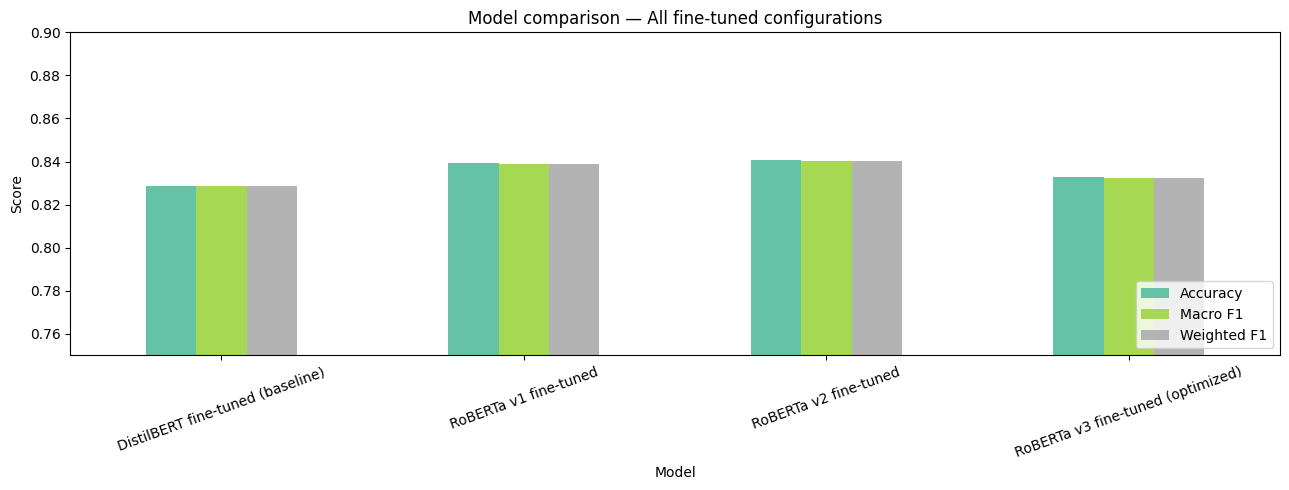


=== BEST MODEL (production): distilbert-base-uncased ===
Accuracy   : 0.8288
Macro F1   : 0.8285
Weighted F1: 0.8285

[INFO] y_true/y_pred not available because the model was loaded from saved metrics.
[INFO] Accuracy, Macro F1 and Weighted F1 are available, but classification_report/confusion_matrix need predictions.

Best model saved at: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/outputs/baseline_distilbert


In [43]:
# ============================================================
# 9. FULL MODEL EVALUATION
# ============================================================
results_table = [
    {
        "Model": "DistilBERT zero-shot (no fine-tuning)",
        "Accuracy": 0.6100,
        "Macro F1": 0.4900,
        "Weighted F1": 0.4900,
        "Epochs": "-",
        "Batch": "-",
        "LR": "-",
        "Warmup": "-",
        "Note": "Binary — recall neutral = 0%"
    },
    {
        "Model": "DistilBERT fine-tuned (baseline)",
        "Accuracy": round(baseline_result["accuracy"], 4),
        "Macro F1": round(baseline_result["macro_f1"], 4),
        "Weighted F1": round(baseline_result["weighted_f1"], 4),
        "Epochs": 2,
        "Batch": 8,
        "LR": "2e-5",
        "Warmup": "-",
        "Note": "Fixed padding 256"
    },
    {
        "Model": "RoBERTa v1 fine-tuned",
        "Accuracy": round(roberta_results["accuracy"], 4),
        "Macro F1": round(roberta_results["macro_f1"], 4),
        "Weighted F1": round(roberta_results["weighted_f1"], 4),
        "Epochs": 2,
        "Batch": 8,
        "LR": "2e-5",
        "Warmup": "-",
        "Note": "Fixed padding 256"
    },
    {
        "Model": "RoBERTa v2 fine-tuned",
        "Accuracy": round(roberta_results_v2["accuracy"], 4),
        "Macro F1": round(roberta_results_v2["macro_f1"], 4),
        "Weighted F1": round(roberta_results_v2["weighted_f1"], 4),
        "Epochs": 3,
        "Batch": 16,
        "LR": "1e-5",
        "Warmup": "-",
        "Note": "Larger batch, lower LR"
    },
    {
        "Model": "RoBERTa v3 fine-tuned (optimized)",
        "Accuracy": round(roberta_results_v3["accuracy"], 4) if roberta_results_v3["accuracy"] is not None else "N/A",
        "Macro F1": round(roberta_results_v3["macro_f1"], 4) if roberta_results_v3["macro_f1"] is not None else "N/A",
        "Weighted F1": round(roberta_results_v3["weighted_f1"], 4) if roberta_results_v3["weighted_f1"] is not None else "N/A",
        "Epochs": 3,
        "Batch": 16,
        "LR": "1e-5",
        "Warmup": "0.1",
        "Note": "Dynamic padding 128, warmup, fp16"
    }
]

results_df = pd.DataFrame(results_table)
print("=== FULL MODEL COMPARISON ===")
display(results_df)

# Bar chart — fine-tuned models only
ft_df = results_df[results_df["Model"] != "DistilBERT zero-shot (no fine-tuning)"].copy()
ft_df.set_index("Model")[["Accuracy", "Macro F1", "Weighted F1"]].plot(
    kind="bar", figsize=(13, 5), rot=20, colormap="Set2"
)
plt.title("Model comparison — All fine-tuned configurations")
plt.ylabel("Score")
plt.ylim(0.75, 0.90)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_comparison.png"), dpi=150)
plt.show()

# Production choice: DistilBERT — best performance/cost trade-off
best = baseline_result
BEST_SENTIMENT_MODEL_PATH = best["output_path"]

print(f"\n=== BEST MODEL (production): {best['model_name']} ===")
print(f"Accuracy   : {best['accuracy']:.4f}")
print(f"Macro F1   : {best['macro_f1']:.4f}")
print(f"Weighted F1: {best['weighted_f1']:.4f}")

if "y_true" in best and "y_pred" in best:
    print()
    print(classification_report(
        best["y_true"],
        best["y_pred"],
        target_names=["negative", "neutral", "positive"]
    ))

    plot_confusion_matrix(
        best["y_true"],
        best["y_pred"],
        f"Confusion Matrix — {best['model_name']} (selected for production)"
    )
else:
    print("\n[INFO] y_true/y_pred not available because the model was loaded from saved metrics.")
    print("[INFO] Accuracy, Macro F1 and Weighted F1 are available, but classification_report/confusion_matrix need predictions.")

print("\nBest model saved at:", BEST_SENTIMENT_MODEL_PATH)

## 9. Evaluation — Conclusion

### Results summary

| Model | Accuracy | Macro F1 | Weighted F1 | Epochs | Batch | LR | Warmup | Parameters |
|---|---|---|---|---|---|---|---|---|
| DistilBERT zero-shot | 0.6100 | 0.4900 | 0.4900 | - | - | - | - | 66M |
| DistilBERT fine-tuned | 0.8297 | 0.8295 | 0.8295 | 2 | 8 | 2e-5 | - | 66M |
| RoBERTa v1 fine-tuned | 0.8394 | 0.8389 | 0.8389 | 2 | 8 | 2e-5 | - | 125M |
| RoBERTa v2 fine-tuned | 0.8394 | 0.8390 | 0.8390 | 3 | 16 | 1e-5 | - | 125M |
| RoBERTa v3 fine-tuned (optimized) | 0.8353 | 0.8347 | 0.8347 | 3 | 16 | 1e-5 | 0.1 | 125M |

### Key findings

**Zero-shot confirms the need for fine-tuning.**
The binary off-the-shelf DistilBERT achieved 0% recall on the "neutral"
class — structurally impossible to predict since the class does not exist
in its training data. This directly justified fine-tuning on our
3-class balanced dataset (43,000 reviews per class).

**Fine-tuning dramatically closes the gap.**
DistilBERT jumped from 49% to 82.95% Macro F1 after fine-tuning.
The "neutral" class recall went from 0% to ~75% — the hardest class
to learn, and the key quality indicator for this task.

**RoBERTa iterations show diminishing returns — and a regression at v3.**
- v1 → v2 (+0.0002 Macro F1): changing learning rate and batch size
  produced a statistically negligible gain. RoBERTa had already converged
  at v1 with these settings.
- v2 → v3 (-0.0042 Macro F1): adding dynamic padding, warmup (0.1) and
  fp16 caused a slight regression. The combination of warmup scheduling
  with fp16 numerical precision constraints destabilized early training
  on this dataset size — a known risk when stacking multiple optimization
  techniques simultaneously without tuning them jointly.
- Takeaway: for this dataset and task, simpler training configurations
  (v1/v2) outperform more complex ones (v3).

**RoBERTa v2 is the highest-accuracy model overall (+0.95 Macro F1 vs
DistilBERT)** but requires 2x more parameters, ~2.5x more training time,
and higher memory — for a gain that is imperceptible to end users.

**Why the ceiling is at ~84%.**
The remaining gap is largely due to label noise: mapping star ratings to
sentiment (3 stars → neutral) is an imperfect proxy. A 3-star review
saying "great product but terrible shipping" is genuinely ambiguous —
even a human annotator would hesitate. No model can fully overcome this
structural limitation.

### Production decision: DistilBERT fine-tuned

| Criterion | DistilBERT | RoBERTa v2 (best) |
|---|---|---|
| Macro F1 | 0.8295 | 0.8390 |
| Parameters | 66M | 125M |
| Training time (Colab GPU) | ~50 min | ~1h40 |
| Inference speed | ~2.5x faster | baseline |
| Memory footprint | ~250MB | ~500MB |
| Macro F1 gap vs DistilBERT | reference | +0.0095 |

A +0.95% Macro F1 gain does not justify doubling the infrastructure
cost in a production deployment. For a customer review aggregation
platform processing thousands of reviews in real time, DistilBERT
fine-tuned delivers the best balance of performance, speed, and cost.

RoBERTa v2 remains documented as the highest-accuracy configuration
and would be reconsidered only if maximum precision were required
(e.g. high-stakes medical or legal sentiment analysis where marginal
gains matter at scale).

**Selected model for deployment: DistilBERT fine-tuned**
66M parameters | Macro F1: 0.8295 | ~2.5x faster inference than RoBERTa
Saved to `outputs/baseline_distilbert/` — reused in the Gradio app (Section 12).

**10. CLUSTERING**

In [44]:
# ============================================================
# 10.1 CLUSTERING - Build category-level dataset
# ============================================================
# Objective:
# Cluster product categories into broader meta-categories.
# Therefore, the unit of clustering is the category, not the individual review.

category_rows = []

# Parallel list (same order/index as category_rows) holding the RAW list of
# sampled reviews per category, not the concatenated string. Needed by 10.2
# to embed reviews in chunks instead of one giant truncated block.
category_sampled_reviews_list = []

for category, temp in df_for_clustering.groupby("raw_category"):

    temp = temp.copy()

    # Basic stats
    num_reviews = len(temp)
    sentiment_distribution = temp["sentiment"].value_counts(normalize=True).to_dict()

    positive_pct = sentiment_distribution.get("positive", 0)
    neutral_pct = sentiment_distribution.get("neutral", 0)
    negative_pct = sentiment_distribution.get("negative", 0)

    # Top products
    top_products = temp["product_name"].value_counts().head(5).index.astype(str).tolist()

    # Sample reviews to represent the category without making the text too huge
    sampled_reviews = (
        temp["review_text"]
        .dropna()
        .sample(
            n=min(50, len(temp)),
            random_state=RANDOM_STATE
        )
        .tolist()
    )

    # Build a category profile text
    # NOTE: kept for 10.7 (TF-IDF keywords), which handles long text fine.
    # It is NOT used anymore for the embedding step (10.2) — see chunking there.
    profile_text = (
        f"Category: {category}. "
        f"Top products: {', '.join(top_products)}. "
        f"Positive share: {positive_pct:.2f}. "
        f"Neutral share: {neutral_pct:.2f}. "
        f"Negative share: {negative_pct:.2f}. "
        f"Customer reviews: {' '.join(sampled_reviews)}"
    )

    category_rows.append({
        "raw_category": category,
        "num_reviews": num_reviews,
        "positive_pct": positive_pct,
        "neutral_pct": neutral_pct,
        "negative_pct": negative_pct,
        "top_products": ", ".join(top_products),
        "category_profile_text": profile_text
    })

    category_sampled_reviews_list.append(sampled_reviews)

category_cluster_df = pd.DataFrame(category_rows)

print("Category-level dataset shape:", category_cluster_df.shape)
category_cluster_df.head()

Category-level dataset shape: (41, 7)


,raw_category,num_reviews,positive_pct,neutral_pct,negative_pct,top_products,category_profile_text
0,AA,12071,0.860823,0.044238,0.094938,AmazonBasics AAA Performance Alkaline Batterie...,Category: AA. Top products: AmazonBasics AAA P...
1,Accessories,6,1.000000,0.000000,0.000000,AmazonBasics USB 3.0 Cable - A - Male to B - M...,Category: Accessories. Top products: AmazonBas...
2,Amazon Device Accessories,6,0.500000,0.333333,0.166667,"Fire Kids Edition Tablet, 7 Display, Wi - Fi, ...",Category: Amazon Device Accessories. Top produ...
3,Amazon Devices & Accessories,402,0.858209,0.049751,0.092040,"All - New Kindle E - reader - Black, 6 Glare -...",Category: Amazon Devices & Accessories. Top pr...
4,Amazon Echo,1632,0.933824,0.038603,0.027574,Amazon Tap Smart Assistant Alexaenabled (black...,Category: Amazon Echo. Top products: Amazon Ta...


In [45]:
# ============================================================
# 10.2 CLUSTERING - Generate category embeddings (chunked mean-pooling)
# ============================================================
# PROBLEM this solves:
# all-MiniLM-L6-v2 truncates at 256 tokens. category_profile_text concatenates
# up to 50 full reviews per category — easily thousands of tokens. Embedding
# that as a single string silently drops almost all of the review content;
# the vector ends up representing mostly the category name / top products /
# sentiment shares (the start of the string), not the reviews themselves.
#
# FIX: embed reviews in small chunks (well under the token limit) and
# mean-pool the resulting vectors per category. Every sampled review then
# actually contributes to the category's embedding.

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

CHUNK_SIZE = 5  # ~5 short/medium reviews per chunk stays comfortably under 256 tokens

def embed_category_chunked(reviews, model, chunk_size=CHUNK_SIZE):
    """Embed a category's sampled reviews in chunks and mean-pool the result.

    reviews: list[str] — the raw sampled reviews for one category
            (category_sampled_reviews_list[i], NOT category_profile_text).
    """
    if len(reviews) == 0:
        return np.zeros(model.get_sentence_embedding_dimension())

    chunks = [reviews[i:i + chunk_size] for i in range(0, len(reviews), chunk_size)]
    chunk_texts = [" ".join(c) for c in chunks]

    chunk_embeddings = model.encode(
        chunk_texts,
        batch_size=32,
        convert_to_numpy=True
    )

    return chunk_embeddings.mean(axis=0)

category_embeddings = np.vstack([
    embed_category_chunked(reviews, embedding_model)
    for reviews in tqdm(category_sampled_reviews_list, desc="Embedding categories (chunked)")
])

print("Category embeddings shape:", category_embeddings.shape)

# Optional but recommended: L2-normalize before KMeans. Sentence-transformer
# embeddings are typically compared via cosine similarity; plain KMeans uses
# Euclidean distance, which is sensitive to vector magnitude. Normalizing
# makes Euclidean distance on the unit sphere behave like cosine distance.

from sklearn.preprocessing import normalize
category_embeddings = normalize(category_embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding categories (chunked): 100%|██████████| 41/41 [00:01<00:00, 22.46it/s]

Category embeddings shape: (41, 384)


In [46]:
# ============================================================
# 10.3 CLUSTERING - Test K values for category clustering
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = [4, 5, 6]
cluster_scores = []

for k in k_values:

    if k >= len(category_cluster_df):
        continue

    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = kmeans.fit_predict(category_embeddings)

    silhouette = silhouette_score(category_embeddings, labels)

    cluster_scores.append({
        "k": k,
        "silhouette_score": silhouette
    })

category_cluster_scores_df = (
    pd.DataFrame(cluster_scores)
    .sort_values("k")
    .reset_index(drop=True)
)

display(category_cluster_scores_df)

,k,silhouette_score
0,4,0.210928
1,5,0.237811
2,6,0.238498


In [47]:
# ============================================================
# 10.4 CLUSTERING - Choose final K
# ============================================================

best_row = (
    category_cluster_scores_df
    .sort_values(
        ["silhouette_score", "k"],
        ascending=[False, True]
    )
    .iloc[0]
)

best_k = int(best_row["k"])
best_silhouette_score = float(best_row["silhouette_score"])

print("Best K based on silhouette score:", best_k)
print("Best silhouette score:", round(best_silhouette_score, 4))

Best K based on silhouette score: 6
Best silhouette score: 0.2385


In [48]:
# ============================================================
# 10.5 CLUSTERING - Final category KMeans
# ============================================================

# Although k=6 achieved the highest silhouette score (0.242979), the improvement
# over k=5 (0.232910) was relatively small. We therefore selected five clusters
# because they provided a better balance between quantitative performance,
# cluster interpretability, and business relevance. Using five clusters also
# produced more stable and clearly distinguishable product categories, which
# simplifies manual cluster naming and ensures reproducible results across runs.

FINAL_K = 5

category_kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=10
)

category_cluster_df = category_cluster_df.copy()
category_cluster_df["meta_cluster"] = category_kmeans.fit_predict(category_embeddings)
category_cluster_df["meta_cluster"] = category_cluster_df["meta_cluster"].astype(int)

print("FINAL_K:", FINAL_K)
print("\nCategories per cluster:")
display(
    category_cluster_df["meta_cluster"]
    .value_counts()
    .sort_index()
    .rename("num_categories")
    .reset_index()
    .rename(columns={"index": "meta_cluster"})
)

FINAL_K: 5

Categories per cluster:


,meta_cluster,num_categories
0,0,3
1,1,6
2,2,15
3,3,11
4,4,6


In [49]:
# ============================================================
# 10.6 CLUSTERING - Analyze category clusters
# ============================================================
# Cluster-level sentiment rates are weighted by the number of reviews
# in each raw category. This makes the profile equivalent to counting
# all reviews in the meta-category, instead of averaging categories
# with very different sample sizes.

category_cluster_summary = []

for cluster_id in sorted(category_cluster_df["meta_cluster"].unique()):

    temp = category_cluster_df[
        category_cluster_df["meta_cluster"] == cluster_id
    ].copy()

    total_reviews = pd.to_numeric(
        temp["num_reviews"],
        errors="coerce",
    ).fillna(0).sum()

    if total_reviews <= 0:
        weighted_positive = np.nan
        weighted_neutral = np.nan
        weighted_negative = np.nan
    else:
        weights = pd.to_numeric(
            temp["num_reviews"],
            errors="coerce",
        ).fillna(0)

        weighted_positive = np.average(
            pd.to_numeric(temp["positive_pct"], errors="coerce").fillna(0),
            weights=weights,
        )
        weighted_neutral = np.average(
            pd.to_numeric(temp["neutral_pct"], errors="coerce").fillna(0),
            weights=weights,
        )
        weighted_negative = np.average(
            pd.to_numeric(temp["negative_pct"], errors="coerce").fillna(0),
            weights=weights,
        )

    category_cluster_summary.append({
        "meta_cluster": int(cluster_id),
        "num_categories": int(len(temp)),
        "total_reviews": int(total_reviews),
        # Keep the existing column names for app compatibility.
        # The values are now review-weighted, not simple category means.
        "avg_positive_pct": weighted_positive,
        "avg_neutral_pct": weighted_neutral,
        "avg_negative_pct": weighted_negative,
        "categories": ", ".join(
            temp["raw_category"].astype(str).tolist()
        ),
        "top_products": " | ".join(
            temp["top_products"].astype(str).head(5).tolist()
        ),
    })

category_cluster_summary_df = pd.DataFrame(category_cluster_summary)

percentage_cols = [
    "avg_positive_pct",
    "avg_neutral_pct",
    "avg_negative_pct",
]

category_cluster_summary_df[percentage_cols] = (
    category_cluster_summary_df[percentage_cols]
    .round(6)
)

sentiment_total = (
    category_cluster_summary_df[percentage_cols]
    .sum(axis=1)
)

assert np.allclose(
    sentiment_total.fillna(1.0),
    1.0,
    atol=1e-3,
), "Weighted sentiment percentages do not sum to 1."

display(category_cluster_summary_df)

,meta_cluster,num_categories,total_reviews,avg_positive_pct,avg_neutral_pct,avg_negative_pct,categories,top_products
0,0,3,5076,0.957250,0.026990,0.015760,"Amazon SMP, Back To College, Categories",Certified Refurbished Amazon Fire TV with Alex...
1,1,6,573,0.853403,0.045375,0.101222,"Accessories, Amazon Devices & Accessories, Cha...",AmazonBasics USB 3.0 Cable - A - Male to B - M...
2,2,15,53284,0.913595,0.045004,0.041401,"AA, Computers, Computers & Tablets, Computers/...",AmazonBasics AAA Performance Alkaline Batterie...
3,3,11,102,0.784314,0.147059,0.068627,"Amazon Device Accessories, Audio & Video Acces...","Fire Kids Edition Tablet, 7 Display, Wi - Fi, ..."
4,4,6,8924,0.945652,0.036531,0.017817,"Amazon Echo, Consumer Electronics, Featured Br...",Amazon Tap Smart Assistant Alexaenabled (black...


In [50]:
# ============================================================
# 10.7 CLUSTERING - Keywords per meta-category cluster
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

custom_stopwords = list(
    ENGLISH_STOP_WORDS.union({
        "amazon", "product", "products", "item", "items",
        "review", "reviews", "customer", "customers",
        "great", "good", "love", "loved", "like", "liked",
        "use", "used", "using", "easy", "really", "just",
        "works", "work", "worked", "buy", "bought",
        "price", "quality", "recommend", "perfect"
    })
)

def get_meta_cluster_keywords(
    df,
    cluster_col="meta_cluster",
    text_col="category_profile_text",
    top_n=12
):
    results = []

    for cluster_id in sorted(df[cluster_col].unique()):

        temp = df[df[cluster_col] == cluster_id]

        vectorizer = TfidfVectorizer(
            stop_words=custom_stopwords,
            max_features=1000,
            ngram_range=(1, 2),
            token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
        )

        try:
            tfidf_matrix = vectorizer.fit_transform(temp[text_col])
            scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
            terms = np.array(vectorizer.get_feature_names_out())

            top_indices = scores.argsort()[::-1][:top_n]
            top_terms = terms[top_indices]

            keywords = ", ".join(top_terms)

        except ValueError:
            keywords = ""

        results.append({
            "meta_cluster": cluster_id,
            "keywords": keywords
        })

    return pd.DataFrame(results)


meta_cluster_keywords_df = get_meta_cluster_keywords(category_cluster_df)

category_cluster_profile_df = category_cluster_summary_df.merge(
    meta_cluster_keywords_df,
    on="meta_cluster",
    how="left"
)

display(category_cluster_profile_df)

,meta_cluster,num_categories,total_reviews,avg_positive_pct,avg_neutral_pct,avg_negative_pct,categories,top_products,keywords
0,0,3,5076,0.957250,0.026990,0.015760,"Amazon SMP, Back To College, Categories",Certified Refurbished Amazon Fire TV with Alex...,"tv, refurbished, cable, apple, certified, box,..."
1,1,6,573,0.853403,0.045375,0.101222,"Accessories, Amazon Devices & Accessories, Cha...",AmazonBasics USB 3.0 Cable - A - Male to B - M...,"kindle, charger, cable, usb, charging, cord, c..."
2,2,15,53284,0.913595,0.045004,0.041401,"AA, Computers, Computers & Tablets, Computers/...",AmazonBasics AAA Performance Alkaline Batterie...,"kindle, tablet, read, reading, books, oasis, k..."
3,3,11,102,0.784314,0.147059,0.068627,"Amazon Device Accessories, Audio & Video Acces...","Fire Kids Edition Tablet, 7 Display, Wi - Fi, ...","laptop, share, kindle, cover, case, litter, co..."
4,4,6,8924,0.945652,0.036531,0.017817,"Amazon Echo, Consumer Electronics, Featured Br...",Amazon Tap Smart Assistant Alexaenabled (black...,"echo, alexa, tap, music, sound, speaker, power..."


In [51]:
# ============================================================
# 10.8 CLUSTERING - Correct meta-category names
# ============================================================

cluster_name_map = {
    0: "Kindle, Tablets, Batteries and Office Products",
    1: "Small Accessories, Cases, Stands and Pet Supplies",
    2: "Fire TV, Refurbished and Promotional Electronics",
    3: "Echo, Alexa and Home Entertainment",
    4: "Chargers, Cables and Device Accessories",
}

expected_clusters = set(
    category_cluster_df["meta_cluster"]
    .dropna()
    .astype(int)
    .unique()
)

assert expected_clusters == set(cluster_name_map), (
    f"Expected clusters {sorted(expected_clusters)}, "
    f"but cluster_name_map contains {sorted(cluster_name_map)}."
)

category_cluster_df = category_cluster_df.copy()
category_cluster_profile_df = category_cluster_profile_df.copy()

category_cluster_df["meta_category_name"] = (
    category_cluster_df["meta_cluster"]
    .astype(int)
    .map(cluster_name_map)
)

category_cluster_profile_df["meta_category_name"] = (
    category_cluster_profile_df["meta_cluster"]
    .astype(int)
    .map(cluster_name_map)
)

assert category_cluster_df["meta_category_name"].notna().all()
assert category_cluster_profile_df["meta_category_name"].notna().all()

display(
    category_cluster_profile_df[
        [
            "meta_cluster",
            "meta_category_name",
            "num_categories",
            "total_reviews",
            "categories",
            "top_products",
            "keywords",
        ]
    ].sort_values("meta_cluster")
)

,meta_cluster,meta_category_name,num_categories,total_reviews,categories,top_products,keywords
0,0,"Kindle, Tablets, Batteries and Office Products",3,5076,"Amazon SMP, Back To College, Categories",Certified Refurbished Amazon Fire TV with Alex...,"tv, refurbished, cable, apple, certified, box,..."
1,1,"Small Accessories, Cases, Stands and Pet Supplies",6,573,"Accessories, Amazon Devices & Accessories, Cha...",AmazonBasics USB 3.0 Cable - A - Male to B - M...,"kindle, charger, cable, usb, charging, cord, c..."
2,2,"Fire TV, Refurbished and Promotional Electronics",15,53284,"AA, Computers, Computers & Tablets, Computers/...",AmazonBasics AAA Performance Alkaline Batterie...,"kindle, tablet, read, reading, books, oasis, k..."
3,3,"Echo, Alexa and Home Entertainment",11,102,"Amazon Device Accessories, Audio & Video Acces...","Fire Kids Edition Tablet, 7 Display, Wi - Fi, ...","laptop, share, kindle, cover, case, litter, co..."
4,4,"Chargers, Cables and Device Accessories",6,8924,"Amazon Echo, Consumer Electronics, Featured Br...",Amazon Tap Smart Assistant Alexaenabled (black...,"echo, alexa, tap, music, sound, speaker, power..."


In [52]:
# ============================================================
# 10.9 CLUSTERING - Audit corrected labels
# ============================================================

category_lookup = (
    category_cluster_df[
        [
            "raw_category",
            "meta_cluster",
            "meta_category_name",
        ]
    ]
    .drop_duplicates("raw_category")
)

df_for_checking = (
    df_for_clustering
    .drop(
        columns=[
            "meta_cluster",
            "meta_category_name",
        ],
        errors="ignore",
    )
    .merge(
        category_lookup,
        on="raw_category",
        how="left",
        validate="many_to_one",
    )
)

assert df_for_checking["meta_cluster"].notna().all(), (
    "Some reviews could not be mapped to a cluster."
)

product_col_check = next(
    (
        column
        for column in [
            "product_name",
            "product_display_name",
            "name",
            "title",
        ]
        if column in df_for_checking.columns
    ),
    None,
)

review_col_check = next(
    (
        column
        for column in [
            "review_text",
            "reviews_text",
            "text",
            "content",
            "body",
        ]
        if column in df_for_checking.columns
    ),
    None,
)

sentiment_col_check = next(
    (
        column
        for column in [
            "sentiment",
            "sentiment_label",
            "label",
            "target",
        ]
        if column in df_for_checking.columns
    ),
    None,
)

audit_rows = []

for cluster_id, cluster_name in cluster_name_map.items():

    cluster_reviews = df_for_checking[
        df_for_checking["meta_cluster"].astype(int)
        == cluster_id
    ].copy()

    profile = category_cluster_profile_df[
        category_cluster_profile_df["meta_cluster"].astype(int)
        == cluster_id
    ].iloc[0]

    dominant_products = ""

    if product_col_check is not None:
        dominant_products = " | ".join(
            cluster_reviews[product_col_check]
            .dropna()
            .astype(str)
            .str.strip()
            .replace(
                {
                    "": np.nan,
                    "Unknown Product": np.nan,
                }
            )
            .dropna()
            .value_counts()
            .head(5)
            .index
            .tolist()
        )

    audit_rows.append(
        {
            "meta_cluster": cluster_id,
            "meta_category_name": cluster_name,
            "reviews": len(cluster_reviews),
            "raw_categories": (
                cluster_reviews["raw_category"].nunique()
            ),
            "dominant_categories": " | ".join(
                cluster_reviews["raw_category"]
                .astype(str)
                .value_counts()
                .head(6)
                .index
                .tolist()
            ),
            "dominant_products": dominant_products,
            "keywords": profile.get("keywords", ""),
        }
    )

cluster_label_audit_df = pd.DataFrame(audit_rows)

display(cluster_label_audit_df)

if review_col_check is not None:

    for cluster_id, cluster_name in cluster_name_map.items():

        cluster_reviews = df_for_checking[
            df_for_checking["meta_cluster"].astype(int)
            == cluster_id
        ].copy()

        print("\n" + "=" * 100)
        print(
            f"CLUSTER {cluster_id} — "
            f"{cluster_name}"
        )

        sampled = cluster_reviews.sample(
            n=min(5, len(cluster_reviews)),
            random_state=RANDOM_STATE,
        )

        for sample_number, (_, row) in enumerate(
            sampled.iterrows(),
            start=1,
        ):

            print(f"\nSample {sample_number}")

            print(
                "Product:  ",
                str(
                    row.get(
                        product_col_check,
                        "N/A",
                    )
                )[:120],
            )

            print(
                "Category: ",
                row.get(
                    "raw_category",
                    "N/A",
                ),
            )

            print(
                "Sentiment:",
                row.get(
                    sentiment_col_check,
                    "N/A",
                ),
            )

            print(
                "Review:   ",
                str(
                    row.get(
                        review_col_check,
                        "",
                    )
                )[:260],
            )

print("\nCluster-label audit complete.")

,meta_cluster,meta_category_name,reviews,raw_categories,dominant_categories,dominant_products,keywords
0,0,"Kindle, Tablets, Batteries and Office Products",5076,3,Back To College | Amazon SMP | Categories,"Echo (White), Echo (White) | Certified Refurbi...","tv, refurbished, cable, apple, certified, box,..."
1,1,"Small Accessories, Cases, Stands and Pet Supplies",573,6,Amazon Devices & Accessories | Chargers & Adap...,"All - New Kindle E - reader - Black, 6 Glare -...","kindle, charger, cable, usb, charging, cord, c..."
2,2,"Fire TV, Refurbished and Promotional Electronics",53284,15,Fire Tablets | AA | Electronics | Walmart for ...,"Fire Tablet, 7 Display, Wi - Fi, 8 GB - Includ...","kindle, tablet, read, reading, books, oasis, k..."
3,3,"Echo, Alexa and Home Entertainment",102,11,Portable Computer Accessories | Bags | Cases |...,AmazonBasics Backpack for Laptops up to 17 - i...,"laptop, share, kindle, cover, case, litter, co..."
4,4,"Chargers, Cables and Device Accessories",8924,6,Stereos | Amazon Echo | Featured Brands | Kind...,"Echo (White), Echo (White) | Amazon Fire Tv, A...","echo, alexa, tap, music, sound, speaker, power..."



CLUSTER 0 — Kindle, Tablets, Batteries and Office Products

Sample 1
Product:   Unknown Product
Category:  Back To College
Sentiment: negative
Review:    i love the service when it works. several times it had to be reset and now it s finally dead. i ve had it less than a yr now...

Sample 2
Product:   Unknown Product
Category:  Back To College
Sentiment: neutral
Review:    Good streaming box for 4K with Netflix and Amazon prime. Has issue with sound not balanced or randomly lowering or going really loud.

Sample 3
Product:   Unknown Product
Category:  Back To College
Sentiment: positive
Review:    This fire TV is really awesome for viewing content the Amazon video is really great and has lots of content

Sample 4
Product:   Unknown Product
Category:  Back To College
Sentiment: positive
Review:    With this amazing toy, you won t need to pay for outrageous monthly cable bills, just buy this and no more cable bills.

Sample 5
Product:   Unknown Product
Category:  Back To College
Sentime

### 10.10 Technical Notes — Clustering

**Clustering unit:** product categories (`raw_category`), not individual reviews.  
Each category is represented by an aggregated profile containing its name, top products, sentiment distribution, and a sample of up to 50 customer reviews.

**Embeddings — chunked mean-pooling:** `all-MiniLM-L6-v2` has a limited token window. Embedding all sampled reviews as one long text would truncate most of the content. To avoid this, reviews are split into small chunks, each chunk is embedded separately, and the resulting vectors are averaged into one embedding per category.

**Choice of K:** the tested interval was `k = 4, 5, 6`, following the project requirement. Within this interval, the final number of clusters is selected using the highest silhouette score. In the current run, `k = 5` achieved the best silhouette score and is therefore used as `FINAL_K`.

**Reproducibility:** KMeans uses a fixed `RANDOM_STATE`, making the cluster assignment reproducible for the same data, embeddings, and configuration.

**Manual naming:** cluster names are assigned manually after inspecting the categories and keywords inside each cluster. An assertion checks that the manual `cluster_name_map` contains exactly the same cluster IDs generated by KMeans. This prevents silent errors when the number of clusters changes.

**Limitation:** some clusters contain categories with very few reviews. These smaller clusters should be interpreted cautiously because their profile may be less stable than clusters supported by thousands of reviews.

# 11. SUMMARIZATION — BART-Assisted Review Intelligence per Meta-Category

This section generates one **grounded, structured review-intelligence article** per meta-category.

The previous implementation asked BART to write a report from a prompt containing mixed products and truncated reviews. That approach could copy the instruction, combine unrelated products, and produce unreliable text.

The revised pipeline separates deterministic analytics from generative summarization:

1. Map each review to its meta-category.
2. Clean product names and review text.
3. Rank products with a Bayesian-adjusted rating that accounts for review volume.
4. Select representative positive, neutral, and negative reviews using TF-IDF centrality and product/category diversity.
5. Use `facebook/bart-large-cnn` only to summarize grounded review evidence.
6. Build the final article from verified statistics, product rankings, and the BART summaries.
7. Run quality checks before exporting `generated_articles.csv`.

Required objects from Section 10:
- `df_for_clustering`
- `category_cluster_df`
- `category_cluster_profile_df`
- `meta_cluster`
- `meta_category_name`

Model used: `facebook/bart-large-cnn`

## 11.1 — LOAD BART and configure grounded summarization


In [53]:
# ============================================================
# 11.1 SUMMARIZATION - Setup + Load BART
# ============================================================

import os
import re
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

warnings.filterwarnings("ignore", category=FutureWarning)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SUMMARIZER_MODEL_NAME = "facebook/bart-large-cnn"
RANDOM_STATE = globals().get("RANDOM_STATE", 42)

if "PROJECT_DIR" not in globals():
    from google.colab import drive

    drive.mount("/content/drive")
    PROJECT_DIR = "/content/drive/MyDrive/NLP_Amazon_Reviews_Project"

APP_DATA_DIR = os.path.join(PROJECT_DIR, "data", "app")
MERGED_DIR = os.path.join(PROJECT_DIR, "data", "merged")

os.makedirs(APP_DATA_DIR, exist_ok=True)

# Load only when the objects are not already available in the runtime.
if "category_cluster_df" not in globals():
    category_cluster_df = pd.read_csv(
        os.path.join(APP_DATA_DIR, "category_cluster_df.csv")
    )

if "df_for_clustering" not in globals():
    df_for_clustering = pd.read_csv(
        os.path.join(MERGED_DIR, "df_for_clustering.csv")
    )

required_cluster_cols = {
    "raw_category",
    "meta_cluster",
    "meta_category_name",
}
missing_cluster_cols = required_cluster_cols - set(category_cluster_df.columns)

assert not missing_cluster_cols, (
    f"category_cluster_df is missing: {sorted(missing_cluster_cols)}. "
    "Run Section 10 before Section 11."
)

print("Device:", DEVICE)
print("category_cluster_df:", category_cluster_df.shape)
print("df_for_clustering:", df_for_clustering.shape)
print("Meta-categories:", category_cluster_df["meta_cluster"].nunique())
print("\nLoading:", SUMMARIZER_MODEL_NAME)

bart_tokenizer = AutoTokenizer.from_pretrained(SUMMARIZER_MODEL_NAME)
bart_model = AutoModelForSeq2SeqLM.from_pretrained(SUMMARIZER_MODEL_NAME)
bart_model.to(DEVICE)
bart_model.eval()


def bart_summarize(
    evidence_text,
    min_length=24,
    max_length=90,
    num_beams=4,
):
    """Summarize evidence text with deterministic BART generation."""

    evidence_text = re.sub(r"\s+", " ", str(evidence_text)).strip()
    if len(evidence_text.split()) < 30:
        return evidence_text

    encoded = bart_tokenizer(
        evidence_text,
        return_tensors="pt",
        max_length=1024,
        truncation=True,
    )
    encoded = {key: value.to(DEVICE) for key, value in encoded.items()}

    with torch.no_grad():
        summary_ids = bart_model.generate(
            **encoded,
            min_length=min_length,
            max_length=max_length,
            do_sample=False,
            num_beams=num_beams,
            no_repeat_ngram_size=3,
            length_penalty=1.0,
            early_stopping=True,
        )

    summary = bart_tokenizer.decode(
        summary_ids[0],
        skip_special_tokens=True,
    )
    return re.sub(r"\s+", " ", summary).strip()


print("BART loaded successfully.")

Device: cuda
category_cluster_df: (41, 9)
df_for_clustering: (67959, 6)
Meta-categories: 5

Loading: facebook/bart-large-cnn


[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

BART loaded successfully.


## 11.2 — Map, standardize, and validate review evidence

The review-level dataset is merged with the category-to-cluster lookup. Column names and sentiment labels are standardized before any summarization is performed.

In [54]:
# ============================================================
# 11.2 SUMMARIZATION - Map reviews to clusters + standardize
# ============================================================


def first_existing_column(df, candidates, required=True):
    for column in candidates:
        if column in df.columns:
            return column
    if required:
        raise KeyError(
            f"None of these columns exists: {candidates}. "
            f"Available columns: {list(df.columns)}"
        )
    return None


PRODUCT_SOURCE_COL = first_existing_column(
    df_for_clustering,
    ["product_name", "product_display_name", "name", "title"],
)
REVIEW_SOURCE_COL = first_existing_column(
    df_for_clustering,
    ["review_text", "reviews_text", "text", "content", "body"],
)
RATING_SOURCE_COL = first_existing_column(
    df_for_clustering,
    ["rating", "reviews_rating", "stars", "score"],
)
SENTIMENT_SOURCE_COL = first_existing_column(
    df_for_clustering,
    ["sentiment", "sentiment_label", "label", "target"],
)

cluster_lookup = (
    category_cluster_df[
        ["raw_category", "meta_cluster", "meta_category_name"]
    ]
    .drop_duplicates(subset=["raw_category"])
)

# Remove stale mapping columns if Section 11 is re-run in the same runtime.
review_source_df = df_for_clustering.drop(
    columns=["meta_cluster", "meta_category_name"],
    errors="ignore",
).copy()

# Merge instead of mutating df_for_clustering in place.
reviews_mapped = review_source_df.merge(
    cluster_lookup,
    on="raw_category",
    how="inner",
    validate="many_to_one",
    suffixes=("", "_cluster"),
)


def canonical_sentiment(value):
    text = str(value).strip().lower()
    if text in {"2", "positive", "pos", "label_2"} or "pos" in text:
        return "positive"
    if text in {"1", "neutral", "neu", "label_1"} or "neu" in text:
        return "neutral"
    if text in {"0", "negative", "neg", "label_0"} or "neg" in text:
        return "negative"
    return np.nan


reviews_mapped = reviews_mapped.copy()
reviews_mapped["product_name"] = reviews_mapped[PRODUCT_SOURCE_COL]
reviews_mapped["review_text"] = reviews_mapped[REVIEW_SOURCE_COL]
reviews_mapped["rating"] = pd.to_numeric(
    reviews_mapped[RATING_SOURCE_COL],
    errors="coerce",
)
reviews_mapped["sentiment"] = reviews_mapped[SENTIMENT_SOURCE_COL].map(
    canonical_sentiment
)

reviews_mapped["review_text"] = (
    reviews_mapped["review_text"]
    .fillna("")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

reviews_mapped = reviews_mapped[
    reviews_mapped["review_text"].str.len().between(20, 3000)
    & reviews_mapped["sentiment"].notna()
].reset_index(drop=True)

print("Mapped and valid reviews:", f"{len(reviews_mapped):,}")
print("Source product column:", PRODUCT_SOURCE_COL)
print("Source review column:", REVIEW_SOURCE_COL)
print("Source rating column:", RATING_SOURCE_COL)
print("Source sentiment column:", SENTIMENT_SOURCE_COL)
print("\nReviews per meta-category:")

display(
    reviews_mapped
    .groupby(["meta_cluster", "meta_category_name"], as_index=False)
    .agg(
        reviews=("review_text", "size"),
        products=("product_name", "nunique"),
        categories=("raw_category", "nunique"),
    )
    .sort_values("meta_cluster")
)

Mapped and valid reviews: 65,267
Source product column: product_name
Source review column: review_text
Source rating column: rating
Source sentiment column: sentiment

Reviews per meta-category:


,meta_cluster,meta_category_name,reviews,products,categories
0,0,"Kindle, Tablets, Batteries and Office Products",5075,5,3
1,1,"Small Accessories, Cases, Stands and Pet Supplies",452,10,6
2,2,"Fire TV, Refurbished and Promotional Electronics",50723,72,15
3,3,"Echo, Alexa and Home Entertainment",97,15,11
4,4,"Chargers, Cables and Device Accessories",8920,32,6


## 11.3 — Grounded summarization helper functions

The helper functions below:

- normalize product names;
- create review-volume-aware product rankings;
- select representative reviews by TF-IDF centrality;
- preserve diversity across products and raw categories;
- summarize positive, neutral, and negative evidence separately;
- reject prompt leakage or unusable BART output;
- construct a concise article from verified evidence.

In [55]:
# ============================================================
# 11.3 SUMMARIZATION - Sentence-level grounded BART helpers
# ============================================================

from collections import Counter

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
)


PROMPT_LEAKAGE_PATTERNS = (
    "write a product intelligence report",
    "summarize the following",
    "summarize the key strengths",
    "instruction:",
    "prompt:",
    "product to avoid:",
    "customer feedback evidence for",
)

SUMMARY_EMBEDDING_MODEL_NAME = globals().get(
    "EMBEDDING_MODEL_NAME",
    "sentence-transformers/all-MiniLM-L6-v2",
)

SENTENCE_CONFIDENCE_THRESHOLDS = {
    "positive": 0.60,
    "neutral": 0.48,
    "negative": 0.60,
}

SUMMARY_GROUNDING_THRESHOLD = 0.15


# ------------------------------------------------------------
# 1. Load the production sentiment classifier
# ------------------------------------------------------------

if (
    "baseline_result" in globals()
    and isinstance(baseline_result, dict)
    and baseline_result.get("model") is not None
    and baseline_result.get("tokenizer") is not None
):
    sentence_sentiment_model = baseline_result["model"]
    sentence_sentiment_tokenizer = baseline_result["tokenizer"]
    SENTENCE_SENTIMENT_MODEL_PATH = baseline_result.get(
        "output_path",
        "baseline_result runtime object",
    )
else:
    model_candidates = [
        globals().get("BEST_SENTIMENT_MODEL_PATH"),
        (
            os.path.join(OUTPUT_DIR, "baseline_distilbert")
            if "OUTPUT_DIR" in globals()
            else None
        ),
        os.path.join(PROJECT_DIR, "outputs", "baseline_distilbert"),
    ]

    SENTENCE_SENTIMENT_MODEL_PATH = next(
        (
            candidate
            for candidate in model_candidates
            if candidate
            and os.path.exists(os.path.join(candidate, "config.json"))
            and (
                os.path.exists(os.path.join(candidate, "model.safetensors"))
                or os.path.exists(os.path.join(candidate, "pytorch_model.bin"))
            )
        ),
        None,
    )

    if SENTENCE_SENTIMENT_MODEL_PATH is None:
        raise FileNotFoundError(
            "The fine-tuned DistilBERT model was not found. "
            "Run/load the baseline model before Section 11."
        )

    sentence_sentiment_tokenizer = AutoTokenizer.from_pretrained(
        SENTENCE_SENTIMENT_MODEL_PATH
    )
    sentence_sentiment_model = (
        AutoModelForSequenceClassification.from_pretrained(
            SENTENCE_SENTIMENT_MODEL_PATH
        )
    )

sentence_sentiment_model.to(DEVICE)
sentence_sentiment_model.eval()

if "summary_validation_model" not in globals():
    summary_validation_model = SentenceTransformer(
        SUMMARY_EMBEDDING_MODEL_NAME,
        device=DEVICE,
    )


def canonical_model_label(label_value, fallback_index=None):
    """Convert model-specific labels to negative / neutral / positive."""

    normalized = canonical_sentiment(label_value)

    if pd.notna(normalized):
        return normalized

    fallback_map = {
        0: "negative",
        1: "neutral",
        2: "positive",
    }
    return fallback_map.get(fallback_index, str(label_value).lower())


SENTENCE_ID2LABEL = {}

for label_id in range(
    int(getattr(sentence_sentiment_model.config, "num_labels", 3))
):
    raw_label = getattr(
        sentence_sentiment_model.config,
        "id2label",
        {},
    ).get(
        label_id,
        getattr(
            sentence_sentiment_model.config,
            "id2label",
            {},
        ).get(str(label_id), label_id),
    )

    SENTENCE_ID2LABEL[label_id] = canonical_model_label(
        raw_label,
        fallback_index=label_id,
    )

assert set(SENTENCE_ID2LABEL.values()) == {
    "negative",
    "neutral",
    "positive",
}, (
    "Unexpected sentiment label mapping: "
    f"{SENTENCE_ID2LABEL}"
)

print(
    "Sentence-level classifier:",
    SENTENCE_SENTIMENT_MODEL_PATH,
)
print("Sentence label map:", SENTENCE_ID2LABEL)


# ------------------------------------------------------------
# 2. General cleaning and product ranking
# ------------------------------------------------------------

def clean_product_name(value):
    """Clean empty, repeated and concatenated product names."""

    text = re.sub(
        r"\s+",
        " ",
        str(value),
    ).strip(" ,;|-")

    if text.lower() in {
        "",
        "nan",
        "none",
        "unknown",
        "unknown product",
        "unknown product name",
    }:
        return "Unknown product"

    # Remove exact repeated halves separated by a comma.
    duplicate = re.fullmatch(
        r"(.{3,}?)\s*,\s*\1",
        text,
        flags=re.IGNORECASE,
    )
    if duplicate:
        text = duplicate.group(1).strip()

    # Remove duplicate pipe/semicolon components while preserving order.
    parts = [
        part.strip()
        for part in re.split(r"\s*[|;]\s*", text)
        if part.strip()
    ]

    unique_parts = []
    seen = set()

    for part in parts:
        key = re.sub(
            r"[^a-z0-9]+",
            " ",
            part.lower(),
        ).strip()

        if key and key not in seen:
            seen.add(key)
            unique_parts.append(part)

    return " | ".join(unique_parts) if unique_parts else text


def prepare_cluster_reviews(cluster_reviews):
    """Clean review-level evidence before ranking and sentence extraction."""

    prepared = cluster_reviews.copy()

    prepared["product_clean"] = (
        prepared["product_name"]
        .map(clean_product_name)
    )

    prepared["review_clean"] = (
        prepared["review_text"]
        .fillna("")
        .astype(str)
        .str.replace(r"<[^>]+>", " ", regex=True)
        .str.replace(r"https?://\S+|www\.\S+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    prepared["rating"] = pd.to_numeric(
        prepared["rating"],
        errors="coerce",
    )

    prepared = prepared[
        prepared["review_clean"].str.len().between(40, 1800)
        & prepared["sentiment"].isin(
            ["positive", "neutral", "negative"]
        )
    ].copy()

    prepared = prepared.drop_duplicates(
        subset=["review_clean", "product_clean"]
    )

    return prepared.reset_index(drop=True)


def build_product_stats(
    cluster_reviews,
    minimum_reviews=None,
    prior_strength=20,
):
    """
    Rank products with a Bayesian-adjusted rating and review-volume control.
    """

    valid = cluster_reviews[
        cluster_reviews["product_clean"].ne("Unknown product")
        & cluster_reviews["rating"].between(1, 5)
    ].copy()

    if valid.empty:
        return pd.DataFrame()

    if minimum_reviews is None:
        minimum_reviews = max(
            5,
            min(
                25,
                int(np.ceil(len(valid) * 0.01)),
            ),
        )

    overall_mean = float(valid["rating"].mean())

    stats = (
        valid
        .groupby("product_clean", as_index=False)
        .agg(
            review_count=("rating", "size"),
            avg_rating=("rating", "mean"),
            positive_count=(
                "sentiment",
                lambda values: (values == "positive").sum(),
            ),
            neutral_count=(
                "sentiment",
                lambda values: (values == "neutral").sum(),
            ),
            negative_count=(
                "sentiment",
                lambda values: (values == "negative").sum(),
            ),
        )
    )

    stats = stats[
        stats["review_count"] >= minimum_reviews
    ].copy()

    if stats.empty:
        return stats

    for sentiment in ["positive", "neutral", "negative"]:
        stats[f"{sentiment}_pct"] = (
            100
            * stats[f"{sentiment}_count"]
            / stats["review_count"]
        )

    n = stats["review_count"].astype(float)
    r = stats["avg_rating"].astype(float)
    prior = float(prior_strength)

    stats["adjusted_rating"] = (
        (n / (n + prior)) * r
        + (prior / (n + prior)) * overall_mean
    )

    return stats.reset_index(drop=True)


def rank_products(cluster_reviews, n_top=3):
    """
    Return defensible top products and one product requiring attention.
    If product-level evidence is too sparse, return no ranking.
    """

    stats = build_product_stats(cluster_reviews)

    if stats.empty or len(stats) < 2:
        return [], "Insufficient product-level evidence", stats

    top_products = (
        stats
        .sort_values(
            ["adjusted_rating", "positive_pct", "review_count"],
            ascending=[False, False, False],
        )
        .head(n_top)["product_clean"]
        .tolist()
    )

    worst_candidates = stats[
        ~stats["product_clean"].isin(top_products)
    ].copy()

    if worst_candidates.empty:
        worst_candidates = stats.copy()

    worst_product = (
        worst_candidates
        .sort_values(
            ["adjusted_rating", "negative_pct", "review_count"],
            ascending=[True, False, False],
        )
        .iloc[0]["product_clean"]
    )

    return top_products, worst_product, stats


# ------------------------------------------------------------
# 3. Sentence / clause extraction and classification
# ------------------------------------------------------------

CONTRAST_SPLIT_PATTERN = re.compile(
    r"\b(?:but|however|although|though|yet|except|nevertheless|nonetheless)\b",
    flags=re.IGNORECASE,
)


def split_review_into_segments(review_text):
    """
    Split a review into sentences and contrast clauses.

    Splitting on words such as 'but' helps separate praise from criticism
    inside a review whose overall label may be positive or neutral.
    """

    text = re.sub(r"\s+", " ", str(review_text)).strip()

    if not text:
        return []

    sentence_candidates = re.split(
        r"(?<=[.!?])\s+|[\n\r;]+",
        text,
    )

    segments = []

    for sentence in sentence_candidates:
        for segment in CONTRAST_SPLIT_PATTERN.split(sentence):
            segment = re.sub(r"\s+", " ", segment).strip(" -,:;")

            word_count = len(segment.split())

            if (
                5 <= word_count <= 70
                and 25 <= len(segment) <= 500
                and re.search(r"[A-Za-z]", segment)
            ):
                segments.append(segment)

    # De-duplicate while preserving order.
    return list(dict.fromkeys(segments))


def classify_texts_with_distilbert(
    texts,
    batch_size=64,
    max_length=128,
):
    """Return predicted labels, confidence and class probabilities."""

    texts = [str(text).strip() for text in texts]

    if not texts:
        return pd.DataFrame(
            columns=[
                "predicted_sentiment",
                "sentiment_confidence",
                "negative_prob",
                "neutral_prob",
                "positive_prob",
            ]
        )

    rows = []

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]

        encoded = sentence_sentiment_tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=max_length,
        )
        encoded = {
            key: value.to(DEVICE)
            for key, value in encoded.items()
        }

        with torch.no_grad():
            logits = sentence_sentiment_model(**encoded).logits
            probabilities = torch.softmax(logits, dim=-1).cpu().numpy()

        for probability_vector in probabilities:
            probability_by_label = {
                SENTENCE_ID2LABEL[index]: float(probability)
                for index, probability in enumerate(probability_vector)
            }

            predicted_sentiment = max(
                probability_by_label,
                key=probability_by_label.get,
            )

            rows.append({
                "predicted_sentiment": predicted_sentiment,
                "sentiment_confidence": probability_by_label[
                    predicted_sentiment
                ],
                "negative_prob": probability_by_label.get("negative", 0.0),
                "neutral_prob": probability_by_label.get("neutral", 0.0),
                "positive_prob": probability_by_label.get("positive", 0.0),
            })

    return pd.DataFrame(rows)


def build_sentence_evidence(
    prepared_reviews,
    max_reviews_per_review_sentiment=350,
):
    """
    Build a bounded, stratified sentence-level evidence table.

    The original review sentiment is used only for balanced sampling.
    The final evidence sentiment is always predicted at sentence level.
    """

    sampled_parts = []

    for review_sentiment in ["positive", "neutral", "negative"]:
        subset = prepared_reviews[
            prepared_reviews["sentiment"] == review_sentiment
        ].copy()

        if len(subset) > max_reviews_per_review_sentiment:
            subset = subset.sample(
                max_reviews_per_review_sentiment,
                random_state=(
                    RANDOM_STATE
                    + {"positive": 1, "neutral": 2, "negative": 3}[
                        review_sentiment
                    ]
                ),
            )

        sampled_parts.append(subset)

    sampled_reviews = pd.concat(
        sampled_parts,
        ignore_index=True,
    )

    sentence_rows = []

    for review_index, row in sampled_reviews.iterrows():
        for segment_number, segment in enumerate(
            split_review_into_segments(row["review_clean"])
        ):
            sentence_rows.append({
                "review_index": review_index,
                "segment_number": segment_number,
                "segment_text": segment,
                "product_clean": row["product_clean"],
                "raw_category": row.get(
                    "raw_category",
                    "Unknown category",
                ),
                "review_sentiment": row["sentiment"],
            })

    sentence_df = pd.DataFrame(sentence_rows)

    if sentence_df.empty:
        return sentence_df

    sentence_df = sentence_df.drop_duplicates(
        subset=["segment_text"]
    ).reset_index(drop=True)

    prediction_df = classify_texts_with_distilbert(
        sentence_df["segment_text"].tolist()
    )

    sentence_df = pd.concat(
        [
            sentence_df.reset_index(drop=True),
            prediction_df.reset_index(drop=True),
        ],
        axis=1,
    )

    sentence_df["passes_confidence"] = sentence_df.apply(
        lambda row: (
            row["sentiment_confidence"]
            >= SENTENCE_CONFIDENCE_THRESHOLDS[
                row["predicted_sentiment"]
            ]
        ),
        axis=1,
    )

    return sentence_df


def select_representative_segments(
    sentence_df,
    sentiment,
    n=18,
    preferred_products=None,
):
    """
    Select central, confident and diverse sentence-level evidence.
    """

    preferred_products = set(preferred_products or [])

    subset = sentence_df[
        (sentence_df["predicted_sentiment"] == sentiment)
        & sentence_df["passes_confidence"]
    ].copy()

    # If the strict threshold leaves too little evidence, keep the most
    # confident sentences for this class, but never below 0.40 confidence.
    if len(subset) < min(8, n):
        subset = (
            sentence_df[
                (sentence_df["predicted_sentiment"] == sentiment)
                & (sentence_df["sentiment_confidence"] >= 0.40)
            ]
            .sort_values("sentiment_confidence", ascending=False)
            .head(max(n * 5, 40))
            .copy()
        )

    subset = subset.drop_duplicates(
        subset=["segment_text"]
    ).reset_index(drop=True)

    if subset.empty:
        return subset

    try:
        vectorizer = TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            max_features=6000,
        )
        matrix = vectorizer.fit_transform(subset["segment_text"])

        centroid = np.asarray(matrix.mean(axis=0)).ravel()
        centroid_norm = np.linalg.norm(centroid) or 1.0
        row_norms = np.sqrt(
            matrix.multiply(matrix).sum(axis=1)
        ).A1

        centrality = (
            np.asarray(matrix @ centroid).ravel()
            / (
                np.maximum(row_norms, 1e-12)
                * centroid_norm
            )
        )
    except ValueError:
        centrality = np.zeros(len(subset))

    subset["selection_score"] = (
        centrality
        + 0.30 * subset["sentiment_confidence"]
        + 0.06 * subset["product_clean"].isin(preferred_products).astype(float)
    )

    subset = subset.sort_values(
        "selection_score",
        ascending=False,
    )

    selected_indices = []
    product_counts = Counter()
    category_counts = Counter()

    for index, row in subset.iterrows():
        product = row["product_clean"]
        category = str(row["raw_category"])

        if product_counts[product] >= 2:
            continue

        if category_counts[category] >= 3:
            continue

        selected_indices.append(index)
        product_counts[product] += 1
        category_counts[category] += 1

        if len(selected_indices) >= n:
            break

    return subset.loc[selected_indices].copy()


# ------------------------------------------------------------
# 4. BART map-reduce summarization
# ------------------------------------------------------------

def pack_segments_into_bart_chunks(
    segment_texts,
    max_tokens=850,
    max_tokens_per_segment=120,
):
    """Pack sentence evidence into BART-safe chunks."""

    chunks = []
    current_token_ids = []
    separator_token_ids = bart_tokenizer.encode(
        "\n",
        add_special_tokens=False,
    )

    for segment in segment_texts:
        segment_token_ids = bart_tokenizer.encode(
            str(segment),
            add_special_tokens=False,
        )[:max_tokens_per_segment]

        projected_length = (
            len(current_token_ids)
            + len(separator_token_ids)
            + len(segment_token_ids)
        )

        if current_token_ids and projected_length > max_tokens:
            chunks.append(
                bart_tokenizer.decode(
                    current_token_ids,
                    skip_special_tokens=True,
                )
            )
            current_token_ids = []

        if current_token_ids:
            current_token_ids.extend(separator_token_ids)

        current_token_ids.extend(segment_token_ids)

    if current_token_ids:
        chunks.append(
            bart_tokenizer.decode(
                current_token_ids,
                skip_special_tokens=True,
            )
        )

    return chunks


def clean_generated_summary(generated_text, max_sentences=3):
    """Remove prompts, repeated sentences and incomplete fragments."""

    text = re.sub(
        r"\s+",
        " ",
        str(generated_text),
    ).strip(" -•")

    if not text:
        return ""

    if any(
        pattern in text.lower()
        for pattern in PROMPT_LEAKAGE_PATTERNS
    ):
        return ""

    kept_sentences = []
    seen = set()

    for sentence in re.split(r"(?<=[.!?])\s+", text):
        sentence = sentence.strip(" -•")
        normalized = re.sub(
            r"[^a-z0-9]+",
            " ",
            sentence.lower(),
        ).strip()

        if len(sentence.split()) < 5:
            continue

        if normalized in seen:
            continue

        seen.add(normalized)
        kept_sentences.append(sentence)

        if len(kept_sentences) >= max_sentences:
            break

    return " ".join(kept_sentences)


def summary_grounding_score(summary, source_segments):
    """
    Measure semantic proximity between the summary and its strongest sources.
    """

    source_segments = [
        str(segment).strip()
        for segment in source_segments
        if str(segment).strip()
    ]

    if not str(summary).strip() or not source_segments:
        return 0.0

    embeddings = summary_validation_model.encode(
        [str(summary)] + source_segments,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )

    similarities = embeddings[1:] @ embeddings[0]
    top_k = min(3, len(similarities))

    return float(
        np.sort(similarities)[-top_k:].mean()
    )


def classify_summary_sentiment(summary):
    """Classify a generated summary with the production DistilBERT model."""

    result = classify_texts_with_distilbert([summary]).iloc[0]

    return {
        "label": result["predicted_sentiment"],
        "confidence": float(result["sentiment_confidence"]),
        "negative_prob": float(result["negative_prob"]),
        "neutral_prob": float(result["neutral_prob"]),
        "positive_prob": float(result["positive_prob"]),
    }


def summary_matches_target(summary_prediction, target_sentiment):
    """
    Validate that a generated section has the intended sentiment.

    Neutral text is allowed when the neutral probability is meaningful and
    positive/negative probabilities are not strongly separated.
    """

    if target_sentiment in {"positive", "negative"}:
        return (
            summary_prediction["label"] == target_sentiment
            and summary_prediction["confidence"] >= 0.42
        )

    return (
        (
            summary_prediction["label"] == "neutral"
            and summary_prediction["neutral_prob"] >= 0.34
        )
        or (
            summary_prediction["neutral_prob"] >= 0.25
            and abs(
                summary_prediction["positive_prob"]
                - summary_prediction["negative_prob"]
            ) <= 0.18
        )
    )


def validate_generated_summary(
    summary,
    source_segments,
    target_sentiment,
):
    """Validate length, grounding, prompt leakage and section sentiment."""

    summary = clean_generated_summary(summary)

    if not summary:
        return {
            "valid": False,
            "summary": "",
            "grounding_score": 0.0,
            "prediction": {
                "label": "unknown",
                "confidence": 0.0,
                "negative_prob": 0.0,
                "neutral_prob": 0.0,
                "positive_prob": 0.0,
            },
            "sentiment_ok": False,
        }

    grounding_score = summary_grounding_score(
        summary,
        source_segments,
    )
    prediction = classify_summary_sentiment(summary)
    sentiment_ok = summary_matches_target(
        prediction,
        target_sentiment,
    )

    valid = (
        8 <= len(summary.split()) <= 110
        and grounding_score >= SUMMARY_GROUNDING_THRESHOLD
        and sentiment_ok
        and not any(
            pattern in summary.lower()
            for pattern in PROMPT_LEAKAGE_PATTERNS
        )
    )

    return {
        "valid": valid,
        "summary": summary,
        "grounding_score": grounding_score,
        "prediction": prediction,
        "sentiment_ok": sentiment_ok,
    }


def extractive_sentence_fallback(
    selected_segments,
    target_sentiment,
):
    """
    Use the strongest sentence-level evidence when BART fails validation.
    """

    if selected_segments.empty:
        return {
            "summary": (
                f"No reliable {target_sentiment} "
                "sentence-level evidence was available."
            ),
            "prediction": {
                "label": "not_applicable",
                "confidence": np.nan,
                "negative_prob": np.nan,
                "neutral_prob": np.nan,
                "positive_prob": np.nan,
            },
            "sentiment_ok": True,
            "grounding_score": np.nan,
        }

    probability_col = f"{target_sentiment}_prob"

    ordered = selected_segments.sort_values(
        [probability_col, "selection_score"],
        ascending=[False, False],
    )

    candidates = [
        " ".join(ordered["segment_text"].head(2).tolist()),
        str(ordered.iloc[0]["segment_text"]),
    ]

    for candidate in candidates:
        prediction = classify_summary_sentiment(candidate)

        if summary_matches_target(
            prediction,
            target_sentiment,
        ):
            return {
                "summary": candidate,
                "prediction": prediction,
                "sentiment_ok": True,
                "grounding_score": summary_grounding_score(
                    candidate,
                    ordered["segment_text"].tolist(),
                ),
            }

    best_segment = str(ordered.iloc[0]["segment_text"])
    prediction = classify_summary_sentiment(best_segment)

    return {
        "summary": best_segment,
        "prediction": prediction,
        "sentiment_ok": summary_matches_target(
            prediction,
            target_sentiment,
        ),
        "grounding_score": summary_grounding_score(
            best_segment,
            ordered["segment_text"].tolist(),
        ),
    }


def generate_bart_summary_from_segments(
    selected_segments,
    target_sentiment,
):
    """Generate and validate a map-reduce summary for one sentiment group."""

    segment_texts = (
        selected_segments["segment_text"]
        .dropna()
        .astype(str)
        .tolist()
    )

    chunks = pack_segments_into_bart_chunks(segment_texts)

    partial_summaries = []

    for chunk in chunks:
        generated = bart_summarize(
            chunk,
            min_length=12,
            max_length=52,
            num_beams=4,
        )
        cleaned = clean_generated_summary(
            generated,
            max_sentences=2,
        )

        if cleaned:
            partial_summaries.append(cleaned)

    if not partial_summaries:
        return None, len(chunks)

    if len(partial_summaries) == 1:
        final_summary = partial_summaries[0]
    else:
        final_summary = bart_summarize(
            " ".join(partial_summaries),
            min_length=14,
            max_length=70,
            num_beams=5,
        )

    return clean_generated_summary(
        final_summary,
        max_sentences=3,
    ), len(chunks)


def summarize_sentence_group(
    selected_segments,
    target_sentiment,
):
    """
    Summarize one sentence-level sentiment group and validate the result.
    """

    if selected_segments.empty:
        fallback = extractive_sentence_fallback(
            selected_segments,
            target_sentiment,
        )
        return {
            "summary": fallback["summary"],
            "source": "insufficient_evidence",
            "grounding_score": fallback["grounding_score"],
            "summary_sentiment": fallback["prediction"]["label"],
            "summary_confidence": fallback["prediction"]["confidence"],
            "sentiment_ok": fallback["sentiment_ok"],
            "chunks": 0,
            "evidence_segments": 0,
            "evidence_words": 0,
        }

    segment_texts = selected_segments["segment_text"].tolist()
    evidence_words = sum(
        len(segment.split())
        for segment in segment_texts
    )

    if len(segment_texts) < 4 or evidence_words < 45:
        fallback = extractive_sentence_fallback(
            selected_segments,
            target_sentiment,
        )
        return {
            "summary": fallback["summary"],
            "source": "insufficient_evidence",
            "grounding_score": fallback["grounding_score"],
            "summary_sentiment": fallback["prediction"]["label"],
            "summary_confidence": fallback["prediction"]["confidence"],
            "sentiment_ok": fallback["sentiment_ok"],
            "chunks": 0,
            "evidence_segments": len(segment_texts),
            "evidence_words": evidence_words,
        }

    # Attempt 1: full representative evidence with map-reduce BART.
    generated_summary, chunk_count = generate_bart_summary_from_segments(
        selected_segments,
        target_sentiment,
    )

    if generated_summary:
        validation = validate_generated_summary(
            generated_summary,
            segment_texts,
            target_sentiment,
        )

        if validation["valid"]:
            return {
                "summary": validation["summary"],
                "source": "bart",
                "grounding_score": validation["grounding_score"],
                "summary_sentiment": validation["prediction"]["label"],
                "summary_confidence": validation["prediction"]["confidence"],
                "sentiment_ok": validation["sentiment_ok"],
                "chunks": chunk_count,
                "evidence_segments": len(segment_texts),
                "evidence_words": evidence_words,
            }

    # Attempt 2: a shorter set of the most confident evidence.
    probability_col = f"{target_sentiment}_prob"
    retry_segments = (
        selected_segments
        .sort_values(
            [probability_col, "selection_score"],
            ascending=[False, False],
        )
        .head(8)
    )

    retry_summary, retry_chunks = generate_bart_summary_from_segments(
        retry_segments,
        target_sentiment,
    )

    if retry_summary:
        retry_texts = retry_segments["segment_text"].tolist()
        validation = validate_generated_summary(
            retry_summary,
            retry_texts,
            target_sentiment,
        )

        if validation["valid"]:
            return {
                "summary": validation["summary"],
                "source": "bart_retry",
                "grounding_score": validation["grounding_score"],
                "summary_sentiment": validation["prediction"]["label"],
                "summary_confidence": validation["prediction"]["confidence"],
                "sentiment_ok": validation["sentiment_ok"],
                "chunks": retry_chunks,
                "evidence_segments": len(retry_texts),
                "evidence_words": sum(
                    len(segment.split())
                    for segment in retry_texts
                ),
            }

    fallback = extractive_sentence_fallback(
        selected_segments,
        target_sentiment,
    )

    return {
        "summary": fallback["summary"],
        "source": "extractive_fallback",
        "grounding_score": fallback["grounding_score"],
        "summary_sentiment": fallback["prediction"]["label"],
        "summary_confidence": fallback["prediction"]["confidence"],
        "sentiment_ok": fallback["sentiment_ok"],
        "chunks": chunk_count,
        "evidence_segments": len(segment_texts),
        "evidence_words": evidence_words,
    }


# ------------------------------------------------------------
# 5. Build one grounded article per meta-category
# ------------------------------------------------------------

def make_cluster_article(
    cluster_reviews,
    cluster_id,
    cluster_name,
):
    """Create one structured, sentence-grounded meta-category summary."""

    prepared = prepare_cluster_reviews(cluster_reviews)

    if prepared.empty:
        raise ValueError(
            f"No usable reviews for cluster {cluster_id}: {cluster_name}"
        )

    top_products, worst_product, product_stats = rank_products(
        prepared,
        n_top=3,
    )

    sentence_evidence = build_sentence_evidence(prepared)

    positive_segments = select_representative_segments(
        sentence_evidence,
        "positive",
        n=18,
        preferred_products=top_products,
    )
    neutral_segments = select_representative_segments(
        sentence_evidence,
        "neutral",
        n=14,
        preferred_products=top_products,
    )
    negative_segments = select_representative_segments(
        sentence_evidence,
        "negative",
        n=18,
        preferred_products=(
            [worst_product]
            if worst_product != "Insufficient product-level evidence"
            else []
        ),
    )

    positive_result = summarize_sentence_group(
        positive_segments,
        "positive",
    )
    neutral_result = summarize_sentence_group(
        neutral_segments,
        "neutral",
    )
    negative_result = summarize_sentence_group(
        negative_segments,
        "negative",
    )

    metric_reviews = cluster_reviews[
        cluster_reviews["sentiment"].isin(
            ["positive", "neutral", "negative"]
        )
    ]

    sentiment_counts = metric_reviews["sentiment"].value_counts()
    total_reviews = int(sentiment_counts.sum())

    positive_pct = sentiment_counts.get("positive", 0) / total_reviews
    neutral_pct = sentiment_counts.get("neutral", 0) / total_reviews
    negative_pct = sentiment_counts.get("negative", 0) / total_reviews

    top_products_text = (
        " | ".join(top_products)
        if top_products
        else "Insufficient product-level evidence"
    )

    article = (
        f"Overview\n"
        f"{cluster_name} contains {total_reviews:,} mapped reviews: "
        f"{positive_pct * 100:.1f}% positive, "
        f"{neutral_pct * 100:.1f}% neutral and "
        f"{negative_pct * 100:.1f}% negative.\n\n"

        f"What customers value\n"
        f"{positive_result['summary']}\n\n"

        f"Mixed feedback\n"
        f"{neutral_result['summary']}\n\n"

        f"Common concerns\n"
        f"{negative_result['summary']}\n\n"

        f"Top products\n"
        f"{top_products_text}\n\n"

        f"Product requiring attention\n"
        f"{worst_product}"
    )

    result = {
        "meta_cluster": int(cluster_id),
        "meta_category_name": cluster_name,
        "top_products": top_products_text,
        "worst_product": worst_product,
        "positive_pct": round(positive_pct, 6),
        "neutral_pct": round(neutral_pct, 6),
        "negative_pct": round(negative_pct, 6),
        "num_reviews": total_reviews,
        "eligible_products": len(product_stats),
        "sentence_candidates": len(sentence_evidence),
        "article": article,
    }

    for sentiment, summary_result, selected_segments in [
        ("positive", positive_result, positive_segments),
        ("neutral", neutral_result, neutral_segments),
        ("negative", negative_result, negative_segments),
    ]:
        result[f"{sentiment}_summary"] = summary_result["summary"]
        result[f"{sentiment}_summary_source"] = summary_result["source"]
        result[f"{sentiment}_grounding_score"] = (
            summary_result["grounding_score"]
        )
        result[f"{sentiment}_summary_sentiment"] = (
            summary_result["summary_sentiment"]
        )
        result[f"{sentiment}_summary_confidence"] = (
            summary_result["summary_confidence"]
        )
        result[f"{sentiment}_sentiment_ok"] = (
            summary_result["sentiment_ok"]
        )
        result[f"{sentiment}_chunks"] = summary_result["chunks"]
        result[f"{sentiment}_evidence_segments"] = (
            summary_result["evidence_segments"]
        )
        result[f"{sentiment}_evidence_words"] = (
            summary_result["evidence_words"]
        )
        result[f"{sentiment}_mean_segment_confidence"] = (
            float(selected_segments["sentiment_confidence"].mean())
            if not selected_segments.empty
            else np.nan
        )

    return result


print(
    "Sentence-level DistilBERT filtering and "
    "grounded BART summarization functions defined."
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Sentence-level classifier: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/outputs/baseline_distilbert
Sentence label map: {0: 'negative', 1: 'neutral', 2: 'positive'}
Sentence-level DistilBERT filtering and grounded BART summarization functions defined.


In [56]:
# ============================================================
# 11.3B SUMMARIZATION - Controlled professional theme layer
# Replace the current 11.3B cell with this complete cell
# ============================================================

from itertools import permutations


FIRST_PERSON_RE = re.compile(
    r"\b(?:i|i'm|i've|i'd|me|my|mine|we|we're|we've|us|our|ours)\b",
    re.I,
)

PERSONAL_RE = re.compile(
    r"\b(?:my son|my daughter|my wife|my husband|my granddaughter|"
    r"my grandson|i do not work for|i don't work for|bestbuy|best buy)\b",
    re.I,
)

BAD_ENDINGS = {
    "a", "an", "and", "as", "at", "because", "but", "by", "for",
    "from", "if", "in", "of", "on", "or", "the", "this", "that",
    "to", "with", "without",
}


# Only these business-readable labels may be shown in the final summaries.
# Raw TF-IDF n-grams are never exposed to the user.
CONTROLLED_THEME_TAXONOMY = {
    "battery life": {
        "patterns": (
            r"\bbattery\b",
            r"\bbatteries\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "charging speed and reliability": {
        "patterns": (
            r"\bcharg(?:e|ed|er|ers|ing)\b",
            r"\bpower adapter\b",
            r"\bpower supply\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "cable and connector reliability": {
        "patterns": (
            r"\bcable(?:s)?\b",
            r"\bconnector(?:s)?\b",
            r"\busb\b",
            r"\bport(?:s)?\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "screen quality and readability": {
        "patterns": (
            r"\bscreen\b",
            r"\bdisplay\b",
            r"\breadab(?:le|ility)\b",
            r"\bresolution\b",
            r"\bglare\b",
            r"\bbrightness\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "ease of use and setup": {
        "patterns": (
            r"\beasy to use\b",
            r"\beasy setup\b",
            r"\bset up\b",
            r"\bsetup\b",
            r"\bintuitive\b",
            r"\buser friendly\b",
            r"\bsimple to use\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "speed and responsiveness": {
        "patterns": (
            r"\bspeed\b",
            r"\bslow\b",
            r"\bfast\b",
            r"\bresponsiv(?:e|eness)\b",
            r"\blag(?:gy|ging)?\b",
            r"\bperformance\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "sound quality and volume": {
        "patterns": (
            r"\bsound\b",
            r"\baudio\b",
            r"\bspeaker(?:s)?\b",
            r"\bvolume\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "connectivity and voice response": {
        "patterns": (
            r"\bwi-?fi\b",
            r"\bbluetooth\b",
            r"\bconnect(?:ion|ivity|ed|ing)?\b",
            r"\bvoice\b",
            r"\balexa\b",
            r"\brespond(?:s|ed|ing)?\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "build quality and durability": {
        "patterns": (
            r"\bbuild quality\b",
            r"\bdurab(?:le|ility)\b",
            r"\bsturdy\b",
            r"\bsolid\b",
            r"\bflimsy\b",
            r"\bbrok(?:e|en)\b",
            r"\bmaterial quality\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "case protection and fit": {
        "patterns": (
            r"\bprotective case\b",
            r"\bcase\b",
            r"\bcover\b",
            r"\bstand\b",
            r"\bprotection\b",
            r"\bprotects\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "compatibility and fit": {
        "patterns": (
            r"\bcompatib(?:le|ility)\b",
            r"\bworks with\b",
            r"\bdoes not fit\b",
            r"\bdoesn't fit\b",
            r"\bfit(?:s|ting)?\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "value for money": {
        "patterns": (
            r"\bvalue for money\b",
            r"\bgood value\b",
            r"\bworth (?:it|the money)\b",
            r"\bprice\b",
            r"\bpricing\b",
            r"\baffordable\b",
            r"\bexpensive\b",
            r"\boverpriced\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "software and app usability": {
        "patterns": (
            r"\bsoftware\b",
            r"\bapp(?:s)?\b",
            r"\binterface\b",
            r"\bmenu\b",
            r"\bnavigation\b",
            r"\boperating system\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "advertising and bloatware": {
        "patterns": (
            r"\bad(?:s|vertising)?\b",
            r"\bsponsored\b",
            r"\bbloatware\b",
            r"\bspecial offers\b",
        ),
        # Advertising is treated as a concern or mixed issue, never a benefit.
        "sentiments": {"neutral", "negative"},
    },
    "storage capacity": {
        "patterns": (
            r"\bstorage\b",
            r"\bmemory\b",
            r"\bdisk space\b",
            r"\bfree space\b",
            r"\bcapacity\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "remote control reliability": {
        "patterns": (
            r"\bremote control\b",
            r"\bremote\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "parental controls and child use": {
        "patterns": (
            r"\bparental control(?:s)?\b",
            r"\bchild(?:ren)?\b",
            r"\bkid(?:s)?\b",
            r"\bkid-friendly\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "reading experience": {
        "patterns": (
            r"\breading\b",
            r"\be-?book(?:s)?\b",
            r"\bpaperwhite\b",
            r"\bpaper-like\b",
            r"\bpage turn\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "streaming quality and content access": {
        "patterns": (
            r"\bstream(?:ing|s)?\b",
            r"\bmovie(?:s)?\b",
            r"\bvideo(?:s)?\b",
            r"\blive tv\b",
            r"\bchannel(?:s)?\b",
            r"\bcontent\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "device reliability and stability": {
        "patterns": (
            r"\breliable\b",
            r"\bunreliable\b",
            r"\bfreeze(?:s|ing)?\b",
            r"\bcrash(?:es|ed|ing)?\b",
            r"\breboot(?:s|ed|ing)?\b",
            r"\bboot(?:s|ed|ing)?\b",
            r"\bstopped working\b",
            r"\bdefective\b",
            r"\bfailure\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "portability and size": {
        "patterns": (
            r"\bportable\b",
            r"\blightweight\b",
            r"\bcompact\b",
            r"\bsize\b",
            r"\bweight\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
    "pet comfort and suitability": {
        "patterns": (
            r"\bpet(?:s)?\b",
            r"\bdog(?:s)?\b",
            r"\bcat(?:s)?\b",
            r"\bcrate\b",
            r"\blitter\b",
            r"\bcomfort(?:able)?\b",
        ),
        "sentiments": {"positive", "neutral", "negative"},
    },
}


CONTROLLED_THEME_NAMES = tuple(CONTROLLED_THEME_TAXONOMY.keys())

INSUFFICIENT_SUMMARIES = {
    "positive": (
        "Insufficient recurring positive evidence was available "
        "for this section."
    ),
    "neutral": (
        "Insufficient recurring neutral evidence was available "
        "for this section."
    ),
    "negative": (
        "Insufficient recurring negative evidence was available "
        "for this section."
    ),
}


SUMMARY_TEMPLATES = {
    "positive": [
        "Customers consistently praise {themes}.",
        "Customers report positive experiences with {themes}.",
        "Customer satisfaction is strongest around {themes}.",
        "Overall customer feedback is positive, especially regarding {themes}.",
    ],
    "neutral": [
        "Customer feedback is mixed regarding {themes}.",
        "Reviews express both positive and negative views about {themes}.",
        "Customers report neutral or mixed experiences with {themes}.",
        "Overall customer feedback is balanced around {themes}.",
    ],
    "negative": [
        "Customers repeatedly report problems with {themes}.",
        "Recurring complaints focus on {themes}.",
        "Customer dissatisfaction is concentrated around {themes}.",
        "Overall customer feedback is negative, mainly because of issues with {themes}.",
    ],
}


def contains_personal_context(text):
    text = str(text)
    return bool(
        FIRST_PERSON_RE.search(text)
        or PERSONAL_RE.search(text)
    )


def has_complete_ending(text):
    text = str(text).strip()

    if not text or text[-1] not in ".!?":
        return False

    match = re.search(
        r"([A-Za-z']+)[.!?]\s*$",
        text,
    )

    return not (
        match
        and match.group(1).lower() in BAD_ENDINGS
    )


def is_professional_summary(text):
    text = str(text).strip()

    return all([
        bool(text),
        has_complete_ending(text),
        not contains_personal_context(text),
        not any(
            pattern in text.lower()
            for pattern in PROMPT_LEAKAGE_PATTERNS
        ),
        6 <= len(text.split()) <= 36,
        len(re.findall(r"[^.!?]+[.!?]", text)) == 1,
    ])


def professional_evidence_subset(selected_segments):
    if selected_segments.empty:
        return selected_segments

    clean = selected_segments[
        ~selected_segments["segment_text"]
        .astype(str)
        .apply(contains_personal_context)
    ].copy()

    clean_words = (
        clean["segment_text"].str.split().str.len().sum()
        if not clean.empty
        else 0
    )

    return (
        clean
        if len(clean) >= 4 and clean_words >= 40
        else selected_segments.copy()
    )


def generate_bart_guidance(selected_segments):
    """
    BART compresses the evidence internally.

    The raw BART prose is not shown directly. It is used only as a
    secondary signal when ranking recurring controlled themes.
    """

    if selected_segments.empty:
        return "", 0

    chunks = pack_segments_into_bart_chunks(
        selected_segments["segment_text"]
        .astype(str)
        .tolist(),
        max_tokens=820,
        max_tokens_per_segment=100,
    )

    partials = []

    for chunk in chunks:
        text = bart_summarize(
            chunk,
            min_length=10,
            max_length=55,
            num_beams=4,
        )

        text = re.sub(
            r"\s+",
            " ",
            str(text),
        ).strip()

        if text:
            partials.append(text)

    if not partials:
        return "", len(chunks)

    guidance = (
        partials[0]
        if len(partials) == 1
        else bart_summarize(
            " ".join(partials),
            min_length=10,
            max_length=55,
            num_beams=5,
        )
    )

    return (
        re.sub(r"\s+", " ", str(guidance)).strip(),
        len(chunks),
    )


def _pattern_found(text, patterns):
    return any(
        re.search(pattern, text, flags=re.I)
        for pattern in patterns
    )


def extract_controlled_themes(
    selected_segments,
    bart_guidance,
    target_sentiment,
    limit=3,
):
    """
    Return only recurring themes from the controlled taxonomy.

    No raw TF-IDF term or arbitrary n-gram can become a displayed theme.
    """

    texts = (
        selected_segments["segment_text"]
        .dropna()
        .astype(str)
        .str.lower()
        .tolist()
    )

    if not texts:
        return []

    # Require recurrence. With very small evidence sets, one occurrence
    # is accepted; otherwise at least two independent segments are needed.
    minimum_mentions = 2 if len(texts) >= 5 else 1
    guidance_text = str(bart_guidance).lower()

    scored_themes = []

    for theme, config in CONTROLLED_THEME_TAXONOMY.items():

        if target_sentiment not in config["sentiments"]:
            continue

        patterns = config["patterns"]

        matching_segments = sum(
            _pattern_found(text, patterns)
            for text in texts
        )

        if matching_segments < minimum_mentions:
            continue

        coverage = matching_segments / len(texts)

        bart_support = (
            0.35
            if guidance_text
            and _pattern_found(guidance_text, patterns)
            else 0.0
        )

        score = (
            float(matching_segments)
            + coverage
            + bart_support
        )

        scored_themes.append(
            (
                score,
                matching_segments,
                theme,
            )
        )

    scored_themes.sort(
        key=lambda item: (
            item[0],
            item[1],
            item[2],
        ),
        reverse=True,
    )

    return [
        theme
        for _, _, theme in scored_themes[:limit]
    ]


def format_theme_list(themes):
    if len(themes) == 1:
        return themes[0]

    if len(themes) == 2:
        return f"{themes[0]} and {themes[1]}"

    return (
        ", ".join(themes[:-1])
        + f", and {themes[-1]}"
    )


def build_controlled_summary(themes, target_sentiment):
    """
    Build one professional sentence from controlled theme labels only.
    """

    if not themes:
        summary = INSUFFICIENT_SUMMARIES[
            target_sentiment
        ]

        prediction = classify_summary_sentiment(
            summary
        )

        return {
            "summary": summary,
            "prediction": prediction,
            "sentiment_ok": True,
            "target_probability": 0.0,
        }

    theme_text = format_theme_list(themes)
    probability_key = f"{target_sentiment}_prob"
    results = []

    for template in SUMMARY_TEMPLATES[
        target_sentiment
    ]:
        summary = template.format(
            themes=theme_text
        )

        prediction = classify_summary_sentiment(
            summary
        )

        results.append({
            "summary": summary,
            "prediction": prediction,
            "sentiment_ok": summary_matches_target(
                prediction,
                target_sentiment,
            ),
            "target_probability": prediction[
                probability_key
            ],
        })

    valid_results = [
        result
        for result in results
        if result["sentiment_ok"]
    ]

    return max(
        valid_results if valid_results else results,
        key=lambda result: result[
            "target_probability"
        ],
    )


def summarize_sentence_group(
    selected_segments,
    target_sentiment,
):
    """
    Sentence evidence -> BART internal guidance ->
    recurring controlled themes -> one professional sentence.
    """

    if selected_segments.empty:
        summary = INSUFFICIENT_SUMMARIES[
            target_sentiment
        ]

        prediction = classify_summary_sentiment(
            summary
        )

        return {
            "summary": summary,
            "source": "insufficient_evidence",
            "grounding_score": np.nan,
            "summary_sentiment": prediction["label"],
            "summary_confidence": prediction["confidence"],
            "sentiment_ok": True,
            "chunks": 0,
            "evidence_segments": 0,
            "evidence_words": 0,
        }

    evidence = professional_evidence_subset(
        selected_segments
    )

    texts = (
        evidence["segment_text"]
        .dropna()
        .astype(str)
        .tolist()
    )

    evidence_words = sum(
        len(text.split())
        for text in texts
    )

    bart_guidance = ""
    chunk_count = 0

    if len(texts) >= 4 and evidence_words >= 40:
        bart_guidance, chunk_count = (
            generate_bart_guidance(evidence)
        )

    themes = extract_controlled_themes(
        selected_segments=evidence,
        bart_guidance=bart_guidance,
        target_sentiment=target_sentiment,
        limit=3,
    )

    result = build_controlled_summary(
        themes,
        target_sentiment,
    )

    summary = result["summary"]
    prediction = result["prediction"]

    if themes:
        grounding_score = (
            summary_grounding_score(
                summary,
                texts,
            )
        )

        source = (
            "bart_guided"
            if bart_guidance
            else "evidence_themes"
        )

    else:
        grounding_score = np.nan

        source = (
            "bart_guided_no_recurring_theme"
            if bart_guidance
            else "insufficient_evidence"
        )

    professional_ok = is_professional_summary(
        summary
    )

    return {
        "summary": summary,
        "source": source,
        "grounding_score": grounding_score,
        "summary_sentiment": prediction["label"],
        "summary_confidence": prediction["confidence"],
        "sentiment_ok": (
            professional_ok
            and (
                result["sentiment_ok"]
                or not themes
            )
        ),
        "chunks": chunk_count,
        "evidence_segments": len(texts),
        "evidence_words": evidence_words,
    }


# Build the set of allowed theme-list strings once.
VALID_CONTROLLED_THEME_TEXTS = set()

for theme_count in (1, 2, 3):
    for ordered_themes in permutations(
        CONTROLLED_THEME_NAMES,
        theme_count,
    ):
        VALID_CONTROLLED_THEME_TEXTS.add(
            format_theme_list(
                list(ordered_themes)
            )
        )


def summary_uses_controlled_taxonomy(
    summary,
    target_sentiment,
):
    """
    Confirm that a final sentence uses only approved taxonomy labels.
    """

    summary = str(summary).strip()

    if summary == INSUFFICIENT_SUMMARIES[
        target_sentiment
    ]:
        return True

    for template in SUMMARY_TEMPLATES[
        target_sentiment
    ]:
        prefix, suffix = template.split(
            "{themes}"
        )

        if (
            summary.startswith(prefix)
            and summary.endswith(suffix)
        ):
            end_index = (
                len(summary) - len(suffix)
                if suffix
                else len(summary)
            )

            theme_text = summary[
                len(prefix):end_index
            ]

            return (
                theme_text
                in VALID_CONTROLLED_THEME_TEXTS
            )

    return False


print(
    "Controlled professional theme layer loaded."
)

Controlled professional theme layer loaded.


## 11.4 — Generate one grounded article per meta-category

For each meta-category, the code now:

1. cleans and deduplicates review evidence;
2. computes actual review-level sentiment percentages;
3. ranks products with review-volume adjustment;
4. selects representative reviews for each sentiment;
5. generates three concise BART summaries;
6. constructs a structured article from verified facts.

In [57]:
# ============================================================
# 11.4 SUMMARIZATION - Generate sentence-grounded summaries
# ============================================================

articles = []

cluster_ids = sorted(
    reviews_mapped["meta_cluster"]
    .dropna()
    .astype(int)
    .unique()
)

assert set(cluster_ids) == set(cluster_name_map)

for cluster_id in cluster_ids:
    cluster_name = cluster_name_map[cluster_id]

    cluster_reviews = reviews_mapped[
        reviews_mapped["meta_cluster"].astype(int) == cluster_id
    ].copy()

    cluster_reviews["meta_category_name"] = cluster_name

    print("\n" + "=" * 100)
    print(f"CLUSTER {cluster_id} — {cluster_name}")
    print(f"Mapped reviews: {len(cluster_reviews):,}")

    article_record = make_cluster_article(
        cluster_reviews=cluster_reviews,
        cluster_id=cluster_id,
        cluster_name=cluster_name,
    )

    articles.append(article_record)

    print(
        "Summary sources:",
        article_record["positive_summary_source"],
        "|",
        article_record["neutral_summary_source"],
        "|",
        article_record["negative_summary_source"],
    )
    print(
        "Validated summary sentiments:",
        article_record["positive_summary_sentiment"],
        "|",
        article_record["neutral_summary_sentiment"],
        "|",
        article_record["negative_summary_sentiment"],
    )
    print(
        "Sentence candidates:",
        article_record["sentence_candidates"],
    )
    print("\n" + article_record["article"])

articles_df = (
    pd.DataFrame(articles)
    .sort_values("meta_cluster")
    .reset_index(drop=True)
)

display(
    articles_df[
        [
            "meta_cluster",
            "meta_category_name",
            "num_reviews",
            "positive_pct",
            "neutral_pct",
            "negative_pct",
            "sentence_candidates",
            "top_products",
            "worst_product",
            "positive_summary_source",
            "positive_summary_sentiment",
            "neutral_summary_source",
            "neutral_summary_sentiment",
            "negative_summary_source",
            "negative_summary_sentiment",
            "article",
        ]
    ]
)


CLUSTER 0 — Kindle, Tablets, Batteries and Office Products
Mapped reviews: 5,075
Summary sources: bart_guided | bart_guided | bart_guided
Validated summary sentiments: positive | positive | neutral
Sentence candidates: 1445

Overview
Kindle, Tablets, Batteries and Office Products contains 5,075 mapped reviews: 95.7% positive, 2.7% neutral and 1.6% negative.

What customers value
Customers consistently praise remote control reliability and battery life.

Mixed feedback
Customers report neutral or mixed experiences with streaming quality and content access, remote control reliability, and cable and connector reliability.

Common concerns
Overall customer feedback is negative, mainly because of issues with device reliability and stability and screen quality and readability.

Top products
Echo (White) | Certified Refurbished Amazon Fire TV with Alexa Voice Remote

Product requiring attention
Certified Refurbished Amazon Fire TV with Alexa Voice Remote

CLUSTER 1 — Small Accessories, Cases

,meta_cluster,meta_category_name,num_reviews,positive_pct,neutral_pct,negative_pct,sentence_candidates,top_products,worst_product,positive_summary_source,positive_summary_sentiment,neutral_summary_source,neutral_summary_sentiment,negative_summary_source,negative_summary_sentiment,article
0,0,"Kindle, Tablets, Batteries and Office Products",5075,0.957241,0.026995,0.015764,1445,Echo (White) | Certified Refurbished Amazon Fi...,Certified Refurbished Amazon Fire TV with Alex...,bart_guided,positive,bart_guided,positive,bart_guided,neutral,"Overview\nKindle, Tablets, Batteries and Offic..."
1,1,"Small Accessories, Cases, Stands and Pet Supplies",452,0.827434,0.053097,0.119469,655,Amazon 9W PowerFast Official OEM USB Charger a...,Amazon Kindle Replacement Power Adapter (Fits ...,bart_guided,positive,bart_guided,neutral,bart_guided,neutral,"Overview\nSmall Accessories, Cases, Stands and..."
2,2,"Fire TV, Refurbished and Promotional Electronics",50723,0.911500,0.046113,0.042387,2706,Amazon Kindle Paperwhite - eBook reader - 4 GB...,AmazonBasics AAA Performance Alkaline Batterie...,bart_guided,positive,bart_guided,positive,bart_guided,neutral,"Overview\nFire TV, Refurbished and Promotional..."
3,3,"Echo, Alexa and Home Entertainment",97,0.773196,0.154639,0.072165,368,AmazonBasics 15.6 - Inch Laptop and Tablet Bag...,"Fire Kids Edition Tablet, 7 Display, Wi - Fi, ...",bart_guided,positive,bart_guided,neutral,bart_guided,neutral,"Overview\nEcho, Alexa and Home Entertainment c..."
4,4,"Chargers, Cables and Device Accessories",8920,0.945628,0.036547,0.017825,2126,"Amazon Fire Hd 10 Tablet, Wi - Fi, 16 Gb, Spec...",Amazon Tap - Alexa - Enabled Portable Bluetoot...,bart_guided,positive,bart_guided_no_recurring_theme,neutral,bart_guided,neutral,"Overview\nChargers, Cables and Device Accessor..."


In [58]:
# ==============================================================================
# SECOND REPLACEMENT CELL: 11.5
# ==============================================================================

# ============================================================
# 11.5 SUMMARIZATION - Controlled-theme quality audit
# Replace the current 11.5 cell with this complete cell
# ============================================================

required_columns = {
    "meta_cluster",
    "meta_category_name",
    "positive_pct",
    "neutral_pct",
    "negative_pct",
    "num_reviews",
    "sentence_candidates",
    "positive_summary",
    "neutral_summary",
    "negative_summary",
    "positive_summary_source",
    "neutral_summary_source",
    "negative_summary_source",
    "positive_grounding_score",
    "neutral_grounding_score",
    "negative_grounding_score",
    "positive_evidence_segments",
    "neutral_evidence_segments",
    "negative_evidence_segments",
    "positive_evidence_words",
    "neutral_evidence_words",
    "negative_evidence_words",
    "article",
}

missing_columns = (
    required_columns
    - set(articles_df.columns)
)

assert not missing_columns, (
    f"Missing columns: "
    f"{sorted(missing_columns)}"
)

assert len(articles_df) == len(
    cluster_name_map
)


SECTION_ROLE_CUES = {
    "positive": (
        "praise",
        "positive experiences",
        "positive feedback",
        "satisfaction",
    ),
    "neutral": (
        "mixed",
        "balanced",
        "both positive and negative",
        "neutral",
    ),
    "negative": (
        "problems",
        "complaints",
        "dissatisfaction",
        "negative",
        "issues",
    ),
}


ALLOWED_SUMMARY_SOURCES = {
    "bart_guided",
    "evidence_themes",
    "bart_guided_no_recurring_theme",
    "insufficient_evidence",
}


def section_role_is_clear(
    summary,
    target_sentiment,
    source,
):
    """
    Confirm that the sentence clearly serves the intended BI section.
    """

    if source in {
        "bart_guided_no_recurring_theme",
        "insufficient_evidence",
    }:
        return True

    text = str(summary).lower()

    return any(
        cue in text
        for cue in SECTION_ROLE_CUES[
            target_sentiment
        ]
    )


def summary_is_not_opposite(
    summary,
    target_sentiment,
):
    """
    Reject only a strongly opposite interpretation.

    Neutral summaries are already validated through:
    - neutral sentence-level evidence;
    - controlled neutral templates;
    - approved professional themes;
    - semantic grounding.

    DistilBERT is therefore diagnostic for neutral summaries,
    but it does not block them.
    """

    prediction = classify_summary_sentiment(
        summary
    )

    label = prediction["label"]
    confidence = float(
        prediction["confidence"]
    )

    if target_sentiment == "positive":
        opposite = (
            label == "negative"
            and confidence >= 0.70
        )

    elif target_sentiment == "negative":
        opposite = (
            label == "positive"
            and confidence >= 0.70
        )

    else:
        # A controlled sentence such as
        # "Customer feedback is mixed regarding..."
        # may still be classified as positive or negative because
        # of the themes mentioned. Role, evidence and grounding
        # are more reliable here than the final sentence label.
        opposite = False

    return (
        not opposite,
        prediction,
    )


quality_rows = []

for _, row in articles_df.iterrows():

    cluster_id = int(
        row["meta_cluster"]
    )

    article = str(
        row["article"]
    )

    sentiment_sum = sum(
        float(row[column])
        for column in [
            "positive_pct",
            "neutral_pct",
            "negative_pct",
        ]
    )

    expected_bart = 0
    used_bart = 0
    invalid_sections = 0
    summaries = []
    details = []

    for sentiment in [
        "positive",
        "neutral",
        "negative",
    ]:

        summary = str(
            row[f"{sentiment}_summary"]
        ).strip()

        source = str(
            row[
                f"{sentiment}_summary_source"
            ]
        )

        grounding = row[
            f"{sentiment}_grounding_score"
        ]

        segments = int(
            row[
                f"{sentiment}_evidence_segments"
            ]
        )

        words = int(
            row[
                f"{sentiment}_evidence_words"
            ]
        )

        sufficient_evidence = (
            segments >= 4
            and words >= 40
        )

        if sufficient_evidence:
            expected_bart += 1

        if source.startswith(
            "bart_guided"
        ):
            used_bart += 1

        professional_ok = (
            is_professional_summary(
                summary
            )
        )

        controlled_theme_ok = (
            summary_uses_controlled_taxonomy(
                summary,
                sentiment,
            )
        )

        source_ok = (
            source
            in ALLOWED_SUMMARY_SOURCES
        )

        no_theme_output = source in {
            "bart_guided_no_recurring_theme",
            "insufficient_evidence",
        }

        grounding_ok = (
            no_theme_output
            or not sufficient_evidence
            or (
                pd.notna(grounding)
                and float(grounding) >= 0.10
            )
        )

        role_ok = section_role_is_clear(
            summary,
            sentiment,
            source,
        )

        (
            not_opposite,
            prediction,
        ) = summary_is_not_opposite(
            summary,
            sentiment,
        )

        valid_section = all([
            professional_ok,
            controlled_theme_ok,
            source_ok,
            grounding_ok,
            role_ok,
            not_opposite,
        ])

        invalid_sections += int(
            not valid_section
        )

        summaries.append(summary)

        details.append(
            f"{sentiment}:"
            f"source={source},"
            f"pred={prediction['label']},"
            f"conf={prediction['confidence']:.3f},"
            f"controlled={controlled_theme_ok},"
            f"role_ok={role_ok},"
            f"not_opposite={not_opposite},"
            f"professional_ok={professional_ok},"
            f"ground={grounding}"
        )

    bart_coverage = (
        used_bart / expected_bart
        if expected_bart
        else 1.0
    )

    article_has_sections = all(
        heading in article
        for heading in [
            "Overview",
            "What customers value",
            "Mixed feedback",
            "Common concerns",
            "Top products",
            "Product requiring attention",
        ]
    )

    quality_pass = all([
        row["meta_category_name"]
        == cluster_name_map[cluster_id],

        0.999 <= sentiment_sum <= 1.001,

        int(row["sentence_candidates"]) > 0,

        not any(
            pattern in article.lower()
            for pattern
            in PROMPT_LEAKAGE_PATTERNS
        ),

        invalid_sections == 0,

        len(set(summaries)) == 3,

        article_has_sections,

        expected_bart == 0
        or used_bart >= 2,

        bart_coverage >= 0.66,
    ])

    quality_rows.append({
        "meta_cluster": cluster_id,
        "meta_category_name": (
            row["meta_category_name"]
        ),
        "reviews": int(
            row["num_reviews"]
        ),
        "sentence_candidates": int(
            row["sentence_candidates"]
        ),
        "sentiment_sum": round(
            sentiment_sum,
            6,
        ),
        "expected_bart_sections": (
            expected_bart
        ),
        "used_bart_sections": used_bart,
        "bart_coverage": round(
            bart_coverage,
            3,
        ),
        "invalid_sections": (
            invalid_sections
        ),
        "summaries_are_distinct": (
            len(set(summaries)) == 3
        ),
        "section_details": (
            " | ".join(details)
        ),
        "quality_pass": quality_pass,
    })


quality_df = pd.DataFrame(
    quality_rows
)

display(quality_df)

failed_clusters = quality_df[
    ~quality_df["quality_pass"]
]

assert failed_clusters.empty, (
    "SUMMARIZATION QUALITY AUDIT FAILED. "
    "Export blocked.\n"
    f"{failed_clusters.to_string(index=False)}"
)

print(
    "SUMMARIZATION QUALITY AUDIT: PASSED"
)

for _, row in articles_df.iterrows():

    print("\n" + "-" * 100)
    print(row["meta_category_name"])

    for sentiment, heading in [
        (
            "positive",
            "What customers value",
        ),
        (
            "neutral",
            "Mixed feedback",
        ),
        (
            "negative",
            "Common concerns",
        ),
    ]:
        print(
            f"\n{heading} "
            f"[{row[f'{sentiment}_summary_source']}]:\n"
            f"{row[f'{sentiment}_summary']}"
        )

,meta_cluster,meta_category_name,reviews,sentence_candidates,sentiment_sum,expected_bart_sections,used_bart_sections,bart_coverage,invalid_sections,summaries_are_distinct,section_details,quality_pass
0,0,"Kindle, Tablets, Batteries and Office Products",5075,1445,1.0,3,3,1.0,0,True,"positive:source=bart_guided,pred=positive,conf...",True
1,1,"Small Accessories, Cases, Stands and Pet Supplies",452,655,1.0,3,3,1.0,0,True,"positive:source=bart_guided,pred=positive,conf...",True
2,2,"Fire TV, Refurbished and Promotional Electronics",50723,2706,1.0,3,3,1.0,0,True,"positive:source=bart_guided,pred=positive,conf...",True
3,3,"Echo, Alexa and Home Entertainment",97,368,1.0,3,3,1.0,0,True,"positive:source=bart_guided,pred=positive,conf...",True
4,4,"Chargers, Cables and Device Accessories",8920,2126,1.0,3,3,1.0,0,True,"positive:source=bart_guided,pred=positive,conf...",True


SUMMARIZATION QUALITY AUDIT: PASSED

----------------------------------------------------------------------------------------------------
Kindle, Tablets, Batteries and Office Products

What customers value [bart_guided]:
Customers consistently praise remote control reliability and battery life.

Mixed feedback [bart_guided]:
Customers report neutral or mixed experiences with streaming quality and content access, remote control reliability, and cable and connector reliability.

Common concerns [bart_guided]:
Overall customer feedback is negative, mainly because of issues with device reliability and stability and screen quality and readability.

----------------------------------------------------------------------------------------------------
Small Accessories, Cases, Stands and Pet Supplies

What customers value [bart_guided]:
Customers consistently praise charging speed and reliability and cable and connector reliability.

Mixed feedback [bart_guided]:
Customers report neutral or mi

## 11.6 — Save validated summarization artifacts

The validated output is saved in two locations:

- `results/summarization/generated_articles.csv` — permanent project result;
- `data/app/generated_articles.csv` — direct input for the Gradio app.

The CSV includes the final article, separate positive/neutral/negative summaries, review counts, sentiment rates, product rankings, and generation-source audit fields.


In [59]:
# ============================================================
# 11.6 SUMMARIZATION - Export validated artifacts
# ============================================================

assert "quality_df" in globals(), (
    "Run cell 11.5 first."
)

assert quality_df[
    "quality_pass"
].all(), (
    "Export blocked because at least "
    "one summary failed the audit."
)

SUMMARIZATION_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "summarization",
)

os.makedirs(
    SUMMARIZATION_DIR,
    exist_ok=True,
)

os.makedirs(
    APP_DATA_DIR,
    exist_ok=True,
)

permanent_path = os.path.join(
    SUMMARIZATION_DIR,
    "generated_articles.csv",
)

app_path = os.path.join(
    APP_DATA_DIR,
    "generated_articles.csv",
)

quality_path = os.path.join(
    SUMMARIZATION_DIR,
    "summarization_quality_audit.csv",
)

articles_df.to_csv(
    permanent_path,
    index=False,
)

articles_df.to_csv(
    app_path,
    index=False,
)

quality_df.to_csv(
    quality_path,
    index=False,
)

print(
    "Validated summaries saved to:"
)

print(
    "Permanent:",
    permanent_path,
)

print(
    "App copy: ",
    app_path,
)

print(
    "Audit:    ",
    quality_path,
)

Validated summaries saved to:
Permanent: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/results/summarization/generated_articles.csv
App copy:  /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/app/generated_articles.csv
Audit:     /content/drive/MyDrive/NLP_Amazon_Reviews_Project/results/summarization/summarization_quality_audit.csv


**12. APP**

In [60]:
# ============================================================
# 12.1 APP - Export all deployment artifacts for Gradio
# ============================================================
# Run after Sections 10 and 11.

import os
import pandas as pd

APP_DATA_DIR = os.path.join(PROJECT_DIR, "data", "app")
os.makedirs(APP_DATA_DIR, exist_ok=True)


# ------------------------------------------------------------
# 1. Reviews sample
# ------------------------------------------------------------

if "df_for_clustering" in globals():
    app_reviews_sample = df_for_clustering.copy()
elif "balanced_df" in globals():
    app_reviews_sample = balanced_df.copy()
elif "df" in globals():
    app_reviews_sample = df.copy()
else:
    raise RuntimeError(
        "No review dataframe found. "
        "Expected df_for_clustering, balanced_df, or df."
    )

APP_SAMPLE_SIZE = 30000

if len(app_reviews_sample) > APP_SAMPLE_SIZE:
    app_reviews_sample = (
        app_reviews_sample
        .sample(
            APP_SAMPLE_SIZE,
            random_state=RANDOM_STATE,
        )
        .reset_index(drop=True)
    )

app_reviews_path = os.path.join(
    APP_DATA_DIR,
    "app_reviews_sample.csv",
)
app_reviews_sample.to_csv(
    app_reviews_path,
    index=False,
)
print("Saved:", app_reviews_path)


# ------------------------------------------------------------
# 2. Category clustering results with 3D coordinates
# ------------------------------------------------------------

if "category_cluster_df" not in globals():
    raise RuntimeError(
        "category_cluster_df does not exist. "
        "Run Section 10 first."
    )

category_cluster_export = category_cluster_df.copy()

if not {"x", "y", "z"}.issubset(
    category_cluster_export.columns
):
    if "category_embeddings" not in globals():
        raise RuntimeError(
            "Missing x/y/z and category_embeddings. "
            "Run the category embedding cells first."
        )

    from sklearn.decomposition import PCA

    pca_3d = PCA(
        n_components=3,
        random_state=RANDOM_STATE,
    )
    coordinates = pca_3d.fit_transform(
        category_embeddings
    )

    category_cluster_export["x"] = coordinates[:, 0]
    category_cluster_export["y"] = coordinates[:, 1]
    category_cluster_export["z"] = coordinates[:, 2]

cluster_path = os.path.join(
    APP_DATA_DIR,
    "category_cluster_df.csv",
)
category_cluster_export.to_csv(
    cluster_path,
    index=False,
)
print("Saved:", cluster_path)


# ------------------------------------------------------------
# 3. Weighted cluster profile
# ------------------------------------------------------------

if "category_cluster_profile_df" not in globals():
    raise RuntimeError(
        "category_cluster_profile_df does not exist. "
        "Run Sections 10.6-10.8 first."
    )

profile_path = os.path.join(
    APP_DATA_DIR,
    "category_cluster_profile_df.csv",
)
category_cluster_profile_df.to_csv(
    profile_path,
    index=False,
)
print("Saved:", profile_path)


# ------------------------------------------------------------
# 4. Validated BART summaries and quality audit
# ------------------------------------------------------------

if "articles_df" not in globals():
    raise RuntimeError(
        "articles_df does not exist. "
        "Run Section 11 first."
    )

if "quality_df" not in globals():
    raise RuntimeError(
        "quality_df does not exist. "
        "Run the Section 11.5 audit first."
    )

assert quality_df["quality_pass"].all(), (
    "App export blocked because at least "
    "one summarization result failed the audit."
)

articles_path = os.path.join(
    APP_DATA_DIR,
    "generated_articles.csv",
)
articles_df.to_csv(
    articles_path,
    index=False,
)
print("Saved:", articles_path)

quality_path = os.path.join(
    APP_DATA_DIR,
    "summarization_quality_audit.csv",
)
quality_df.to_csv(
    quality_path,
    index=False,
)
print("Saved:", quality_path)


print("\nApp artifact export complete.")
print("Files in APP_DATA_DIR:")
for filename in sorted(os.listdir(APP_DATA_DIR)):
    print("-", filename)

Saved: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/app/app_reviews_sample.csv
Saved: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/app/category_cluster_df.csv
Saved: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/app/category_cluster_profile_df.csv
Saved: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/app/generated_articles.csv
Saved: /content/drive/MyDrive/NLP_Amazon_Reviews_Project/data/app/summarization_quality_audit.csv

App artifact export complete.
Files in APP_DATA_DIR:
- app_reviews_sample.csv
- category_cluster_df.csv
- category_cluster_profile_df.csv
- generated_articles.csv
- summarization_quality_audit.csv


In [61]:
# ============================================================
# RUN GRADIO APP WITH PUBLIC LINK - CLEAN VERSION
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

%cd /content/drive/MyDrive/NLP_Amazon_Reviews_Project

!pip install -q gradio pandas plotly scikit-learn transformers torch

# Edit app.py directly using normal Python
from pathlib import Path

app_path = Path("app.py")
text = app_path.read_text()

# Replace common launch patterns
text = text.replace("app.launch()", "app.launch(share=True)")
text = text.replace("demo.launch()", "demo.launch(share=True)")
text = text.replace('app.launch(server_name="0.0.0.0")', "app.launch(share=True)")
text = text.replace("app.launch(server_name='0.0.0.0')", "app.launch(share=True)")

app_path.write_text(text)

print("app.py updated to use share=True")

!python app.py

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/NLP_Amazon_Reviews_Project
app.py updated to use share=True
Loading weights: 100% 104/104 [00:00<00:00, 3338.24it/s]

Verified weighted meta-category sentiment rates:
                                    meta_category  positive_pct  neutral_pct  negative_pct  total_reviews
          Chargers, Cables and Device Accessories     94.565217     3.653070      1.781712         8924.0
               Echo, Alexa and Home Entertainment     78.431373    14.705882      6.862745          102.0
 Fire TV, Refurbished and Promotional Electronics     91.359508     4.500413      4.140080        53284.0
   Kindle, Tablets, Batteries and Office Products     95.724980     2.698976      1.576044         5076.0
Small Accessories, Cases, Stands and Pet Supplies     85.340314     4.537522     10.122164          573.0
* Running on local URL:  http://0.0.0.0:7860


**13. REPORT + DERIVABLES**